# Step 9 – K-Means Clustering: City Roles in the Open-AI Ecosystem

**RQ1**: *What distinct roles do global cities play in the ecosystem of prominent open-AI projects, such as originators, collaboration hubs, bridge cities, and late adopters?*

This notebook:
1. Selects and transforms clustering variables based on EDA findings
2. Determines the optimal number of clusters (elbow + silhouette)
3. Fits K-means and interprets each cluster as a city role
4. Visualises results on a global map and via radar / profile charts

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

DATA = Path('..') / 'data' / 'output'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
print(f'Loaded {len(city_attr)} cities × {city_attr.shape[1]} columns')

Loaded 148 cities × 28 columns


## 9.1 – Feature Selection & Transformation

Based on EDA findings:
- `collaboration_count` ≡ `weighted_degree` (ρ = 1.0) → keep only `weighted_degree`
- Activity variables are heavily right-skewed → apply `log1p`
- All inputs must be z-score standardised for K-means
- Include both absolute-scale and per-capita indicators to capture distinct role dimensions

In [2]:
# Select clustering features
# Dimension 1: Innovation intensity (origination)
# Dimension 2: Adoption breadth
# Dimension 3: Network position (hub vs periphery)
# Dimension 4: Bridge role (betweenness)
# Dimension 5: Per-capita innovation (captures small but intense cities)

df = city_attr.copy()

# Apply log1p to skewed absolute variables
df['log_origination'] = np.log1p(df['origination_count'])
df['log_adoption']    = np.log1p(df['adoption_count'])
df['log_degree']      = np.log1p(df['weighted_degree'])
df['log_betweenness'] = np.log1p(df['betweenness'] * 1000)  # scale up before log
df['log_orig_rate']   = np.log1p(df['origination_rate_pop'])

cluster_features = [
    'log_origination',   # innovation volume
    'log_adoption',      # adoption breadth
    'log_degree',        # network centrality
    'log_betweenness',   # bridge / intermediary role
    'log_orig_rate',     # per-capita innovation intensity
]

X_raw = df[cluster_features].copy()
print('Clustering features (after log1p):')
print(X_raw.describe().round(3).to_string())
print(f'\nSkewness:')
for c in cluster_features:
    print(f'  {c:25s}  {X_raw[c].skew():+.2f}')

Clustering features (after log1p):
       log_origination  log_adoption  log_degree  log_betweenness  log_orig_rate
count          148.000       148.000     148.000          148.000        148.000
mean             2.366         4.787       7.210            1.302          1.659
std              1.640         1.220       1.080            1.110          1.557
min              0.000         1.386       4.174            0.000          0.000
25%              1.099         4.003       6.552            0.373          0.462
50%              2.197         4.738       7.151            0.997          1.194
75%              3.178         5.554       7.948            1.970          2.329
max              7.497         8.232       9.498            4.831          8.543

Skewness:
  log_origination            +0.79
  log_adoption               +0.25
  log_degree                 -0.21
  log_betweenness            +0.90
  log_orig_rate              +1.42


In [3]:
# Drop rows with NaN (some cities lack population data for origination_rate_pop)
X_raw = X_raw.dropna()
print(f'Rows after dropping NaN: {len(X_raw)} (dropped {len(df) - len(X_raw)})')

# Standardise (z-score)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_df = pd.DataFrame(X, columns=cluster_features, index=X_raw.index)

print('\nAfter standardisation:')
print(X_df.describe().round(3).to_string())

Rows after dropping NaN: 148 (dropped 0)

After standardisation:
       log_origination  log_adoption  log_degree  log_betweenness  log_orig_rate
count          148.000       148.000     148.000          148.000        148.000
mean             0.000         0.000      -0.000            0.000         -0.000
std              1.003         1.003       1.003            1.003          1.003
min             -1.447        -2.796      -2.820           -1.176         -1.070
25%             -0.775        -0.645      -0.611           -0.839         -0.772
50%             -0.103        -0.040      -0.055           -0.276         -0.300
75%              0.497         0.631       0.686            0.604          0.432
max              3.139         2.833       2.126            3.190          4.437


## 9.2 – Optimal k Selection

  k= 2  inertia=   372.5  silhouette=0.3985
  k= 3  inertia=   239.2  silhouette=0.3858
  k= 4  inertia=   186.2  silhouette=0.3525


  k= 5  inertia=   150.3  silhouette=0.3772


  k= 6  inertia=   131.5  silhouette=0.3132
  k= 7  inertia=   114.1  silhouette=0.3275
  k= 8  inertia=    98.6  silhouette=0.3268
  k= 9  inertia=    87.1  silhouette=0.3237
  k=10  inertia=    81.0  silhouette=0.3075


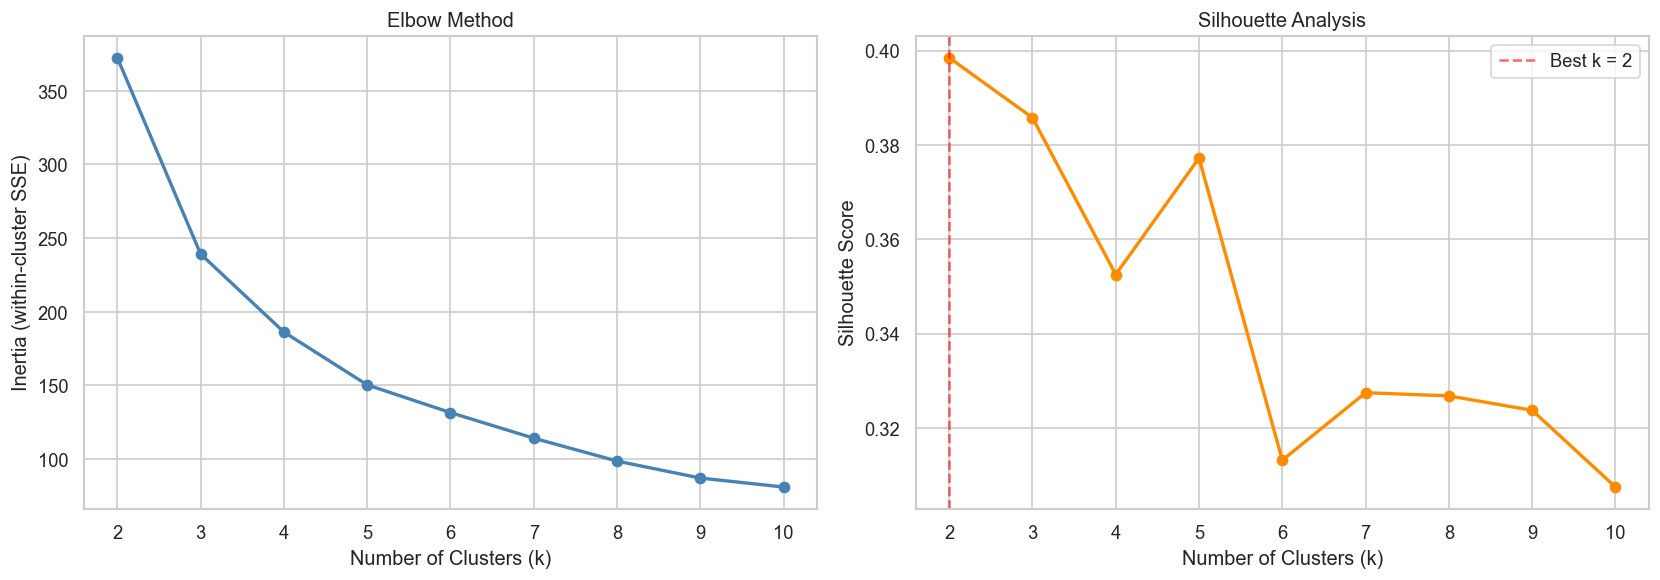


Best silhouette at k = 2 (0.3985)


In [4]:
# Elbow method + Silhouette score
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouettes.append(sil)
    print(f'  k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(K_range))

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', ls='--', alpha=0.6,
                label=f'Best k = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBest silhouette at k = {best_k} ({max(silhouettes):.4f})')

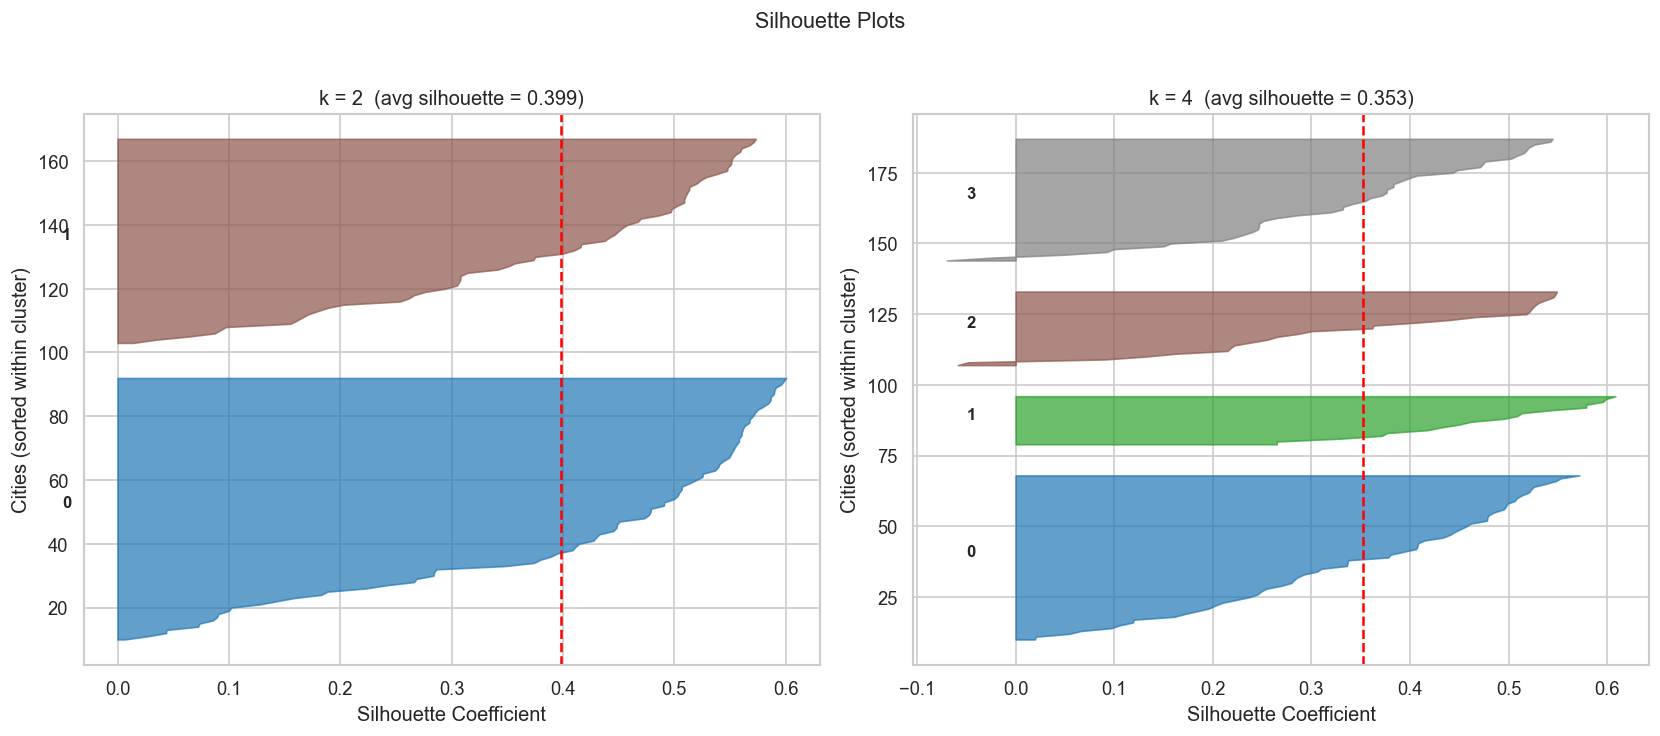

In [5]:
# Silhouette plot for the chosen k
# We test both the silhouette-optimal k and k=4 (theory-driven: 4 roles)
test_ks = sorted(set([best_k, 4]))

fig, axes = plt.subplots(1, len(test_ks), figsize=(7 * len(test_ks), 6))
if len(test_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, test_ks):
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_sil = silhouette_score(X, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', ls='--', lw=1.5)
    ax.set_title(f'k = {k}  (avg silhouette = {avg_sil:.3f})', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cities (sorted within cluster)')

plt.suptitle('Silhouette Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9.3 – Final Clustering (k = 4)

We use **k = 4** as our primary model, matching the four theoretically motivated roles:
originators, collaboration hubs, bridge cities, and peripheral / late adopters.
If the silhouette-optimal k differs, we compare both.

In [6]:
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=500)
labels = km_final.fit_predict(X)

df['cluster'] = np.nan
df.loc[X_raw.index, 'cluster'] = labels

print(f'Cluster sizes (k = {CHOSEN_K}):')
print(df['cluster'].value_counts().sort_index().to_string())
print(f'\nSilhouette score: {silhouette_score(X, labels):.4f}')

Cluster sizes (k = 4):
cluster
0.0    20
1.0    27
2.0    59
3.0    42

Silhouette score: 0.3494


In [7]:
# Cluster profiles: mean of original (untransformed) variables
profile_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'adoption_rate_pop',
    'collaboration_rate_pop', 'avg_lag', 'entity_count',
    'population_million', 'gdp_per_capita', 'research_capacity',
]

profiles = df.groupby('cluster')[profile_cols].mean().round(2)
profiles['n_cities'] = df.groupby('cluster').size()

print('Cluster Profiles (mean values):')
display(profiles.T)

Cluster Profiles (mean values):


cluster,0.0,1.0,2.0,3.0
origination_count,1.60,275.37,15.14,3.45
adoption_count,20.65,942.07,183.53,59.07
weighted_degree,238.40,6353.07,2191.39,790.45
betweenness,0.03,0.00,0.00,0.01
origination_rate_pop,1.26,282.03,10.33,2.90
adoption_rate_pop,12.59,742.77,106.94,56.40
collaboration_rate_pop,150.79,5982.10,1306.04,730.63
avg_lag,9.49,5.61,8.70,9.39
entity_count,15.35,671.52,130.66,42.76
population_million,5.91,8.73,6.29,5.00


In [8]:
# Assign interpretive role labels based on cluster profiles
# Sort clusters by origination_count descending to assign labels
cluster_order = profiles.sort_values('origination_count', ascending=False).index.tolist()

# Heuristic label assignment:
# Highest origination + adoption + degree → "Global Innovation Hub"
# Second highest, high collaboration → "Active Collaborator"
# Moderate activity, possibly high per-capita → "Emerging Contributor"
# Lowest activity → "Peripheral / Late Adopter"

role_names_ordered = [
    'Global Innovation Hub',
    'Active Collaborator',
    'Emerging Contributor',
    'Peripheral / Late Adopter',
]

role_map = {}
for i, cluster_id in enumerate(cluster_order):
    if i < len(role_names_ordered):
        role_map[cluster_id] = role_names_ordered[i]
    else:
        role_map[cluster_id] = f'Cluster {cluster_id}'

df['role'] = df['cluster'].map(role_map)

print('Role assignments:')
for cid, role in sorted(role_map.items()):
    n = (df['cluster'] == cid).sum()
    mean_orig = df.loc[df['cluster'] == cid, 'origination_count'].mean()
    mean_adopt = df.loc[df['cluster'] == cid, 'adoption_count'].mean()
    mean_deg = df.loc[df['cluster'] == cid, 'weighted_degree'].mean()
    print(f'  Cluster {cid} → {role:30s}  (n={n:3d}, '
          f'orig={mean_orig:.0f}, adopt={mean_adopt:.0f}, degree={mean_deg:.0f})')

Role assignments:
  Cluster 0.0 → Peripheral / Late Adopter       (n= 20, orig=2, adopt=21, degree=238)
  Cluster 1.0 → Global Innovation Hub           (n= 27, orig=275, adopt=942, degree=6353)
  Cluster 2.0 → Active Collaborator             (n= 59, orig=15, adopt=184, degree=2191)
  Cluster 3.0 → Emerging Contributor            (n= 42, orig=3, adopt=59, degree=790)


## 9.4 – Cluster Visualisation

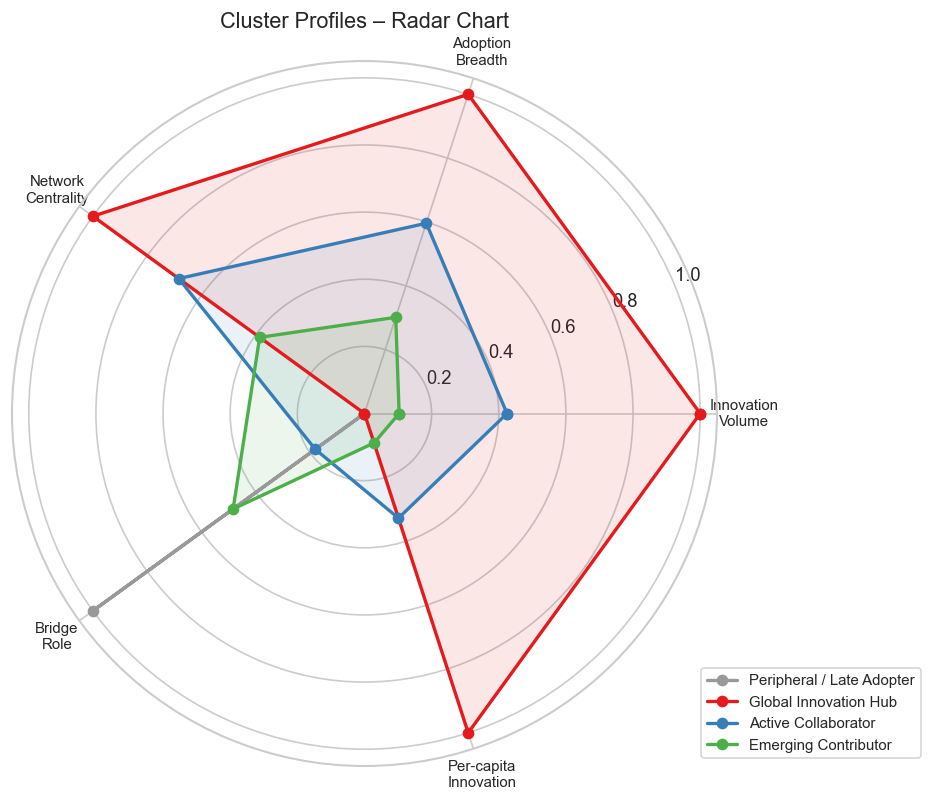

In [9]:
# Radar / spider chart: normalised cluster centroids
radar_cols = ['log_origination', 'log_adoption', 'log_degree',
              'log_betweenness', 'log_orig_rate']
radar_labels = ['Innovation\nVolume', 'Adoption\nBreadth', 'Network\nCentrality',
                'Bridge\nRole', 'Per-capita\nInnovation']

centroids_std = pd.DataFrame(km_final.cluster_centers_, columns=cluster_features)
# Min-max normalise centroids to [0, 1] for radar
centroids_norm = (centroids_std - centroids_std.min()) / (centroids_std.max() - centroids_std.min() + 1e-9)

n_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

role_colors = {
    'Global Innovation Hub': '#e41a1c',
    'Active Collaborator': '#377eb8',
    'Emerging Contributor': '#4daf4a',
    'Peripheral / Late Adopter': '#999999',
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cid in range(CHOSEN_K):
    role = role_map[cid]
    vals = centroids_norm.iloc[cid][radar_cols].tolist()
    vals += vals[:1]
    color = role_colors.get(role, 'grey')
    ax.plot(angles, vals, 'o-', lw=2, label=role, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title('Cluster Profiles – Radar Chart', fontsize=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=9)
plt.tight_layout()
plt.show()

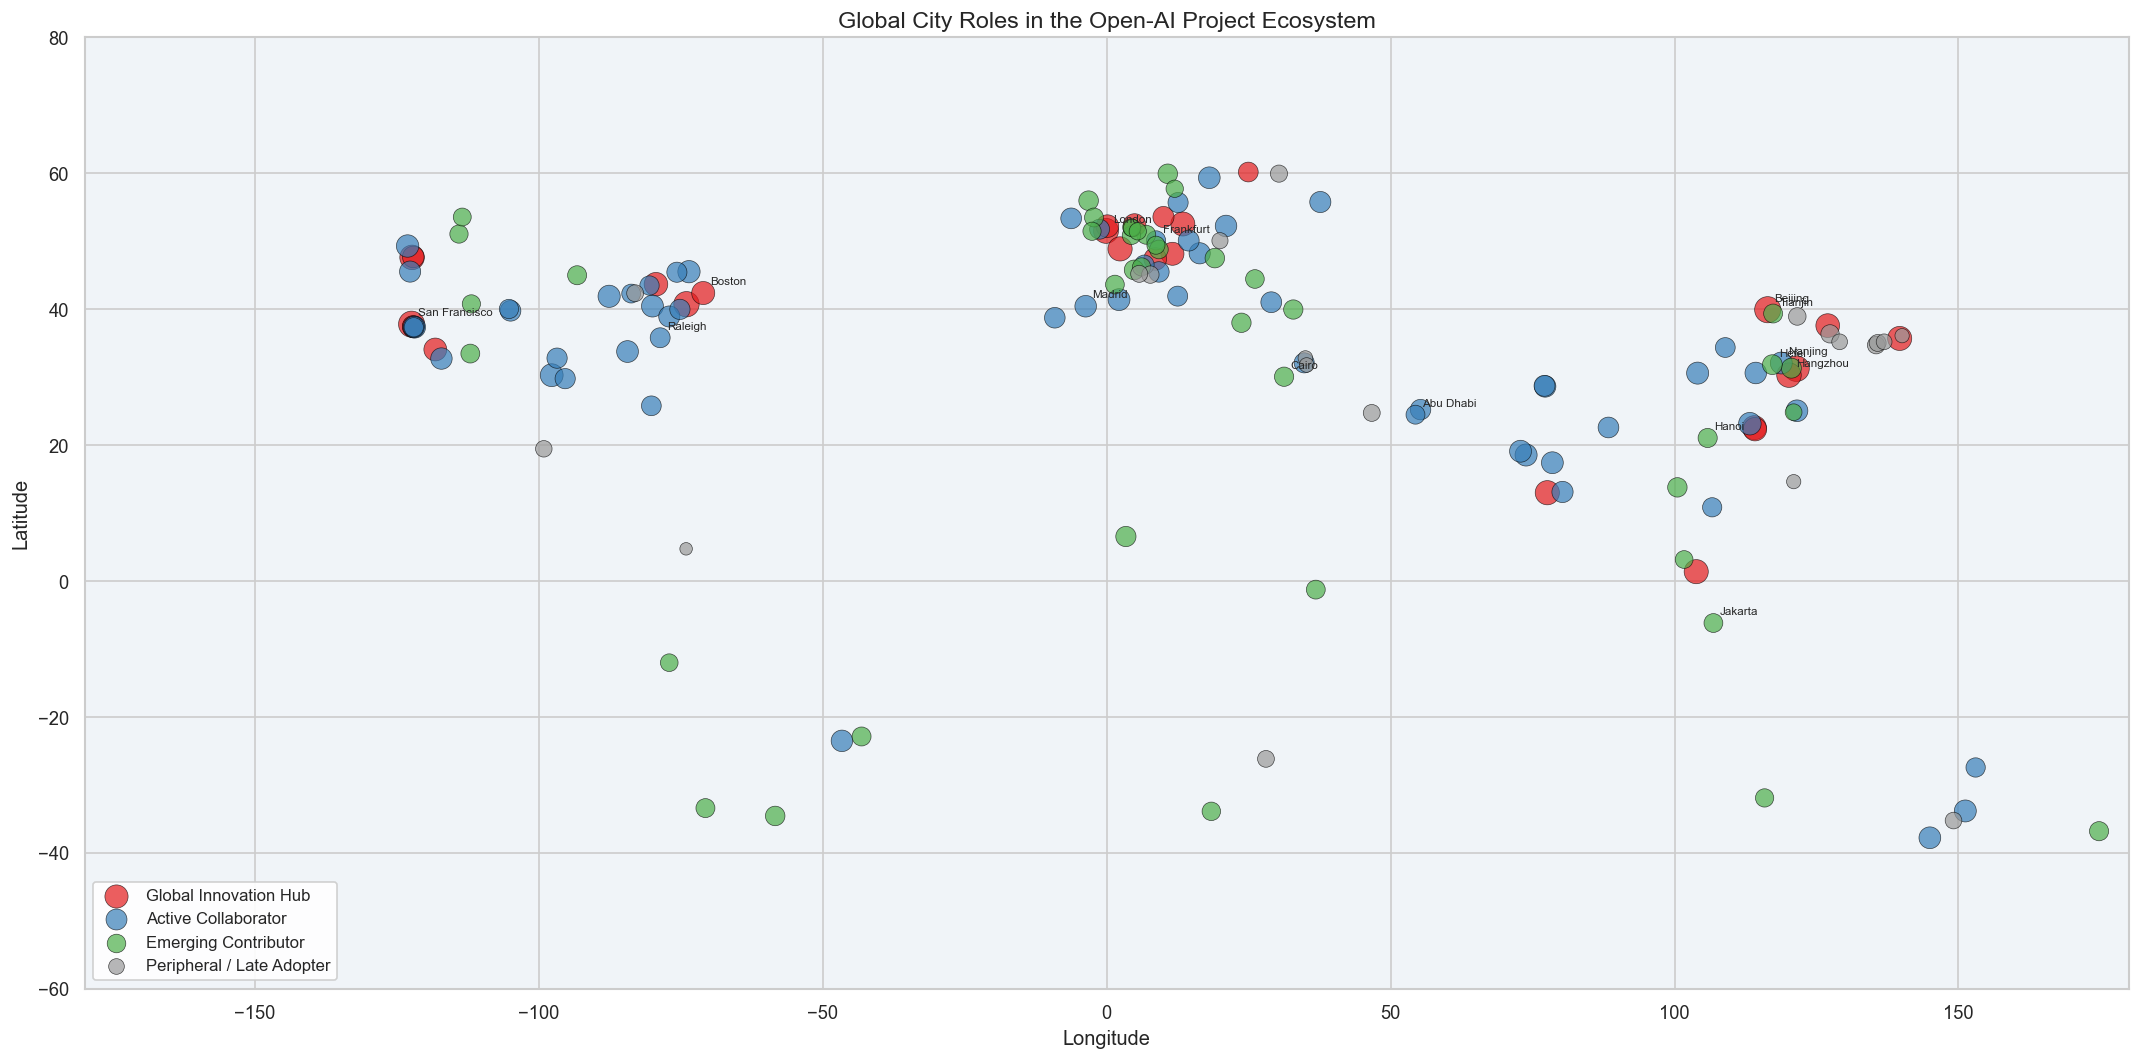

In [10]:
# Global map: cities coloured by cluster role
fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#f0f4f8')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)

# Bubble size ~ log(entity_count)
sizes = np.log1p(df['entity_count']) * 30 + 15

for role in role_names_ordered:
    mask = df['role'] == role
    color = role_colors.get(role, 'grey')
    ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
               s=sizes[mask], c=color, alpha=0.7,
               edgecolors='black', linewidths=0.4, label=role, zorder=3)

# Label top cities per cluster
for role in role_names_ordered[:3]:  # label top roles
    subset = df[df['role'] == role].nlargest(5, 'origination_count')
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Global City Roles in the Open-AI Project Ecosystem', fontsize=14)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

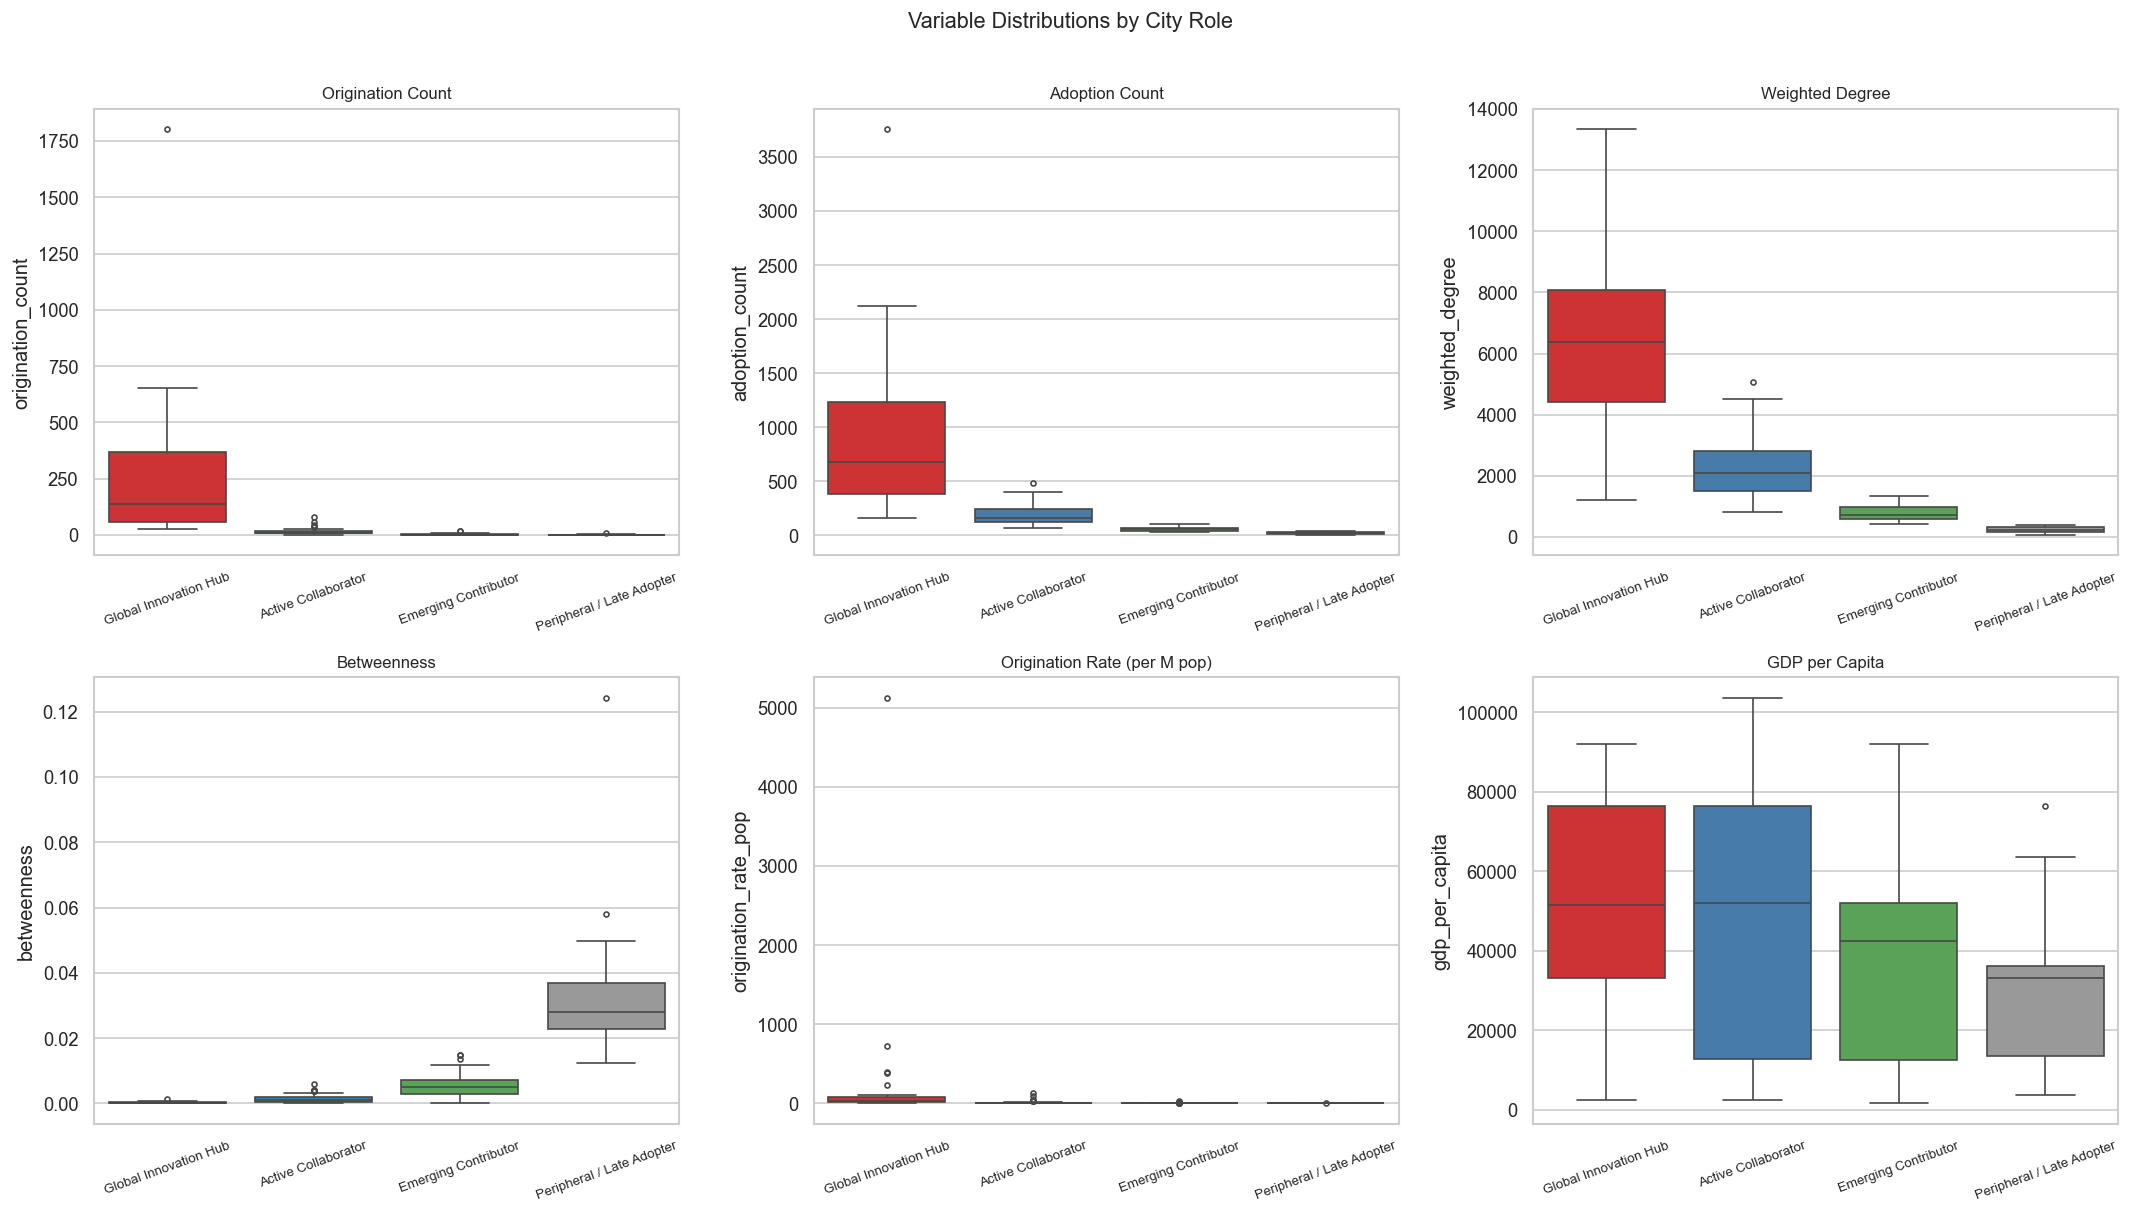

In [11]:
# Box plots: key variables by role
box_vars = [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
    ('weighted_degree', 'Weighted Degree'),
    ('betweenness', 'Betweenness'),
    ('origination_rate_pop', 'Origination Rate (per M pop)'),
    ('gdp_per_capita', 'GDP per Capita'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, title) in zip(axes.flatten(), box_vars):
    order = role_names_ordered
    palette = [role_colors[r] for r in order]
    sns.boxplot(data=df, x='role', y=col, order=order, palette=palette,
                ax=ax, fliersize=3)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_xlabel('')

plt.suptitle('Variable Distributions by City Role', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

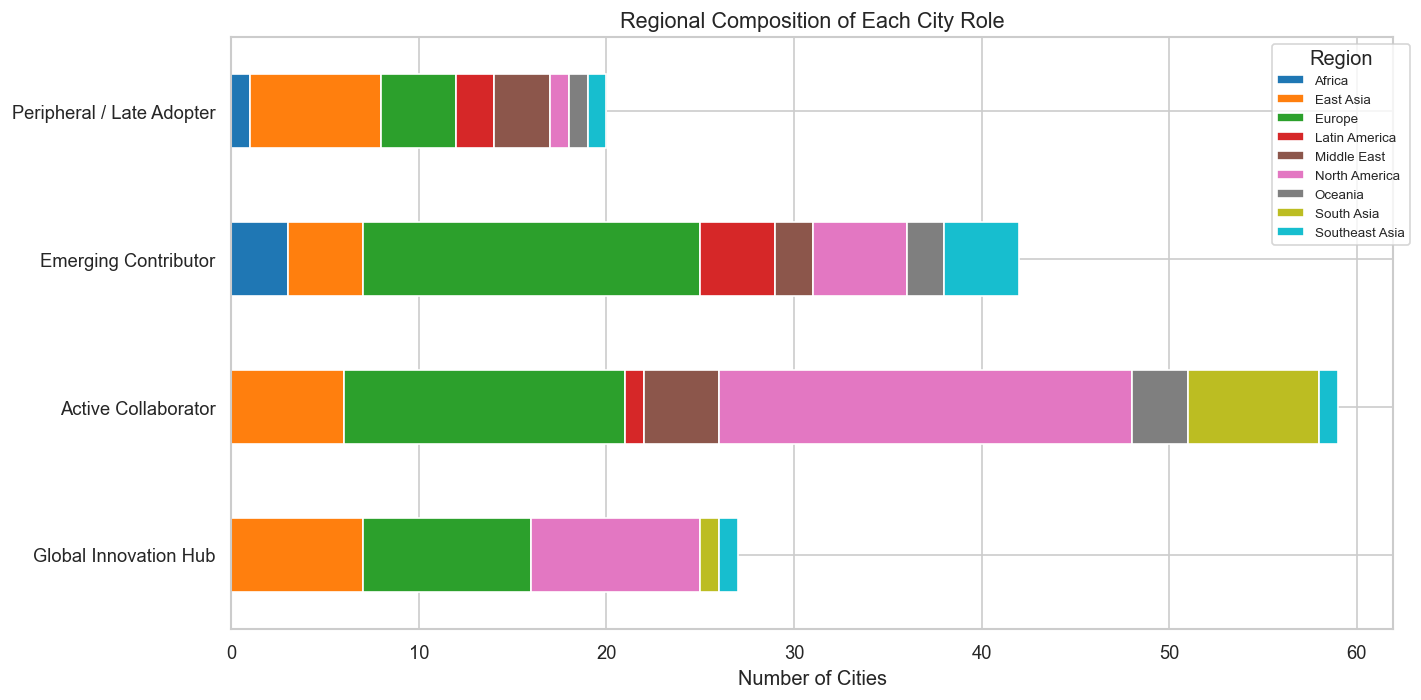

Regional composition:


region,Africa,East Asia,Europe,Latin America,Middle East,North America,Oceania,South Asia,Southeast Asia
role,,,,,,,,,
Global Innovation Hub,0,7,9,0,0,9,0,1,1
Active Collaborator,0,6,15,1,4,22,3,7,1
Emerging Contributor,3,4,18,4,2,5,2,0,4
Peripheral / Late Adopter,1,7,4,2,3,1,1,0,1


In [12]:
# Regional composition of each cluster
role_region = pd.crosstab(df['role'], df['region'])
role_region = role_region.loc[role_names_ordered]

fig, ax = plt.subplots(figsize=(12, 6))
role_region.plot.barh(stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Regional Composition of Each City Role', fontsize=13)
ax.set_xlabel('Number of Cities')
ax.set_ylabel('')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('Regional composition:')
display(role_region)

In [13]:
# List representative cities in each cluster
print('=' * 70)
print('REPRESENTATIVE CITIES BY ROLE')
print('=' * 70)

for role in role_names_ordered:
    subset = df[df['role'] == role].sort_values('origination_count', ascending=False)
    n = len(subset)
    top_cities = subset.head(min(10, n))

    print(f'\n▸ {role} ({n} cities)')
    for _, row in top_cities.iterrows():
        print(f'    {row["city"]:20s} ({row["country"]:15s})  '
              f'orig={row["origination_count"]:5.0f}  '
              f'adopt={row["adoption_count"]:6.0f}  '
              f'degree={row["weighted_degree"]:7.0f}')

REPRESENTATIVE CITIES BY ROLE

▸ Global Innovation Hub (27 cities)
    San Francisco        (United States  )  orig= 1802  adopt=  3757  degree=  13337
    Beijing              (China          )  orig=  653  adopt=  2126  degree=  10471
    London               (United Kingdom )  orig=  633  adopt=  1784  degree=  10389
    Hangzhou             (China          )  orig=  533  adopt=  1233  degree=   6463
    Boston               (United States  )  orig=  513  adopt=   910  degree=   5051
    New York             (United States  )  orig=  496  adopt=  1594  degree=  11214
    Seattle              (United States  )  orig=  382  adopt=  1226  degree=   8762
    Redmond              (United States  )  orig=  359  adopt=   478  degree=   2357
    Paris                (France         )  orig=  288  adopt=   934  degree=   7000
    Shanghai             (China          )  orig=  269  adopt=  1416  degree=   9198

▸ Active Collaborator (59 cities)
    Frankfurt            (Germany        )  orig

## 9.5 – Save Results

In [14]:
# Save cluster assignments back to city_attributes
city_attr['cluster'] = df['cluster']
city_attr['role'] = df['role']
city_attr.to_csv(DATA / 'city_attributes.csv', index=False)
print(f'✅ Saved cluster & role columns to city_attributes.csv')

print(f'\n📊 Final cluster summary:')
summary = df.groupby('role').agg(
    n_cities=('city', 'count'),
    mean_origination=('origination_count', 'mean'),
    mean_adoption=('adoption_count', 'mean'),
    mean_degree=('weighted_degree', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    mean_gdp=('gdp_per_capita', 'mean'),
    top_city=('origination_count', lambda x: df.loc[x.idxmax(), 'city']),
).round(2)
display(summary)

✅ Saved cluster & role columns to city_attributes.csv

📊 Final cluster summary:


,n_cities,mean_origination,mean_adoption,mean_degree,mean_betweenness,mean_gdp,top_city
role,,,,,,,
Active Collaborator,59,15.14,183.53,2191.39,0.00,46445.66,Frankfurt
Emerging Contributor,42,3.45,59.07,790.45,0.01,35823.33,Hanoi
Global Innovation Hub,27,275.37,942.07,6353.07,0.00,49953.33,San Francisco
Peripheral / Late Adopter,20,1.60,20.65,238.40,0.03,31267.05,Daejeon


---

## 9.6 – K-Means Parameter Sensitivity Analysis

Compare **k = 3, 4, 5** with increased `n_init = 50` for more stable centroid initialisation.
We evaluate each configuration on silhouette score, Calinski–Harabasz index, and Davies–Bouldin index.

In [15]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

N_INIT_HIGH = 50
test_k_values = [3, 4, 5]

kmeans_results = {}

for k in test_k_values:
    km = KMeans(n_clusters=k, n_init=N_INIT_HIGH, random_state=42, max_iter=500)
    labs = km.fit_predict(X)

    sil = silhouette_score(X, labs)
    ch  = calinski_harabasz_score(X, labs)
    db  = davies_bouldin_score(X, labs)

    kmeans_results[k] = {
        'model': km,
        'labels': labs,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'inertia': km.inertia_,
    }

    print(f'k={k}  |  Silhouette={sil:.4f}  |  CH={ch:.1f}  |  DB={db:.3f}  |  Inertia={km.inertia_:.1f}')

comp_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m not in ('model', 'labels')}
    for k, vals in kmeans_results.items()
}).T
comp_df.index.name = 'k'
print('\n── K-Means Comparison Table (n_init=50) ──')
display(comp_df.round(4))

k=3  |  Silhouette=0.3858  |  CH=151.8  |  DB=0.869  |  Inertia=239.2
k=4  |  Silhouette=0.3479  |  CH=143.0  |  DB=0.959  |  Inertia=186.0
k=5  |  Silhouette=0.3772  |  CH=140.2  |  DB=0.907  |  Inertia=150.3

── K-Means Comparison Table (n_init=50) ──


,silhouette,calinski_harabasz,davies_bouldin,inertia
k,,,,
3,0.3858,151.7979,0.8694,239.1908
4,0.3479,142.9872,0.9589,185.9811
5,0.3772,140.2086,0.9066,150.3479


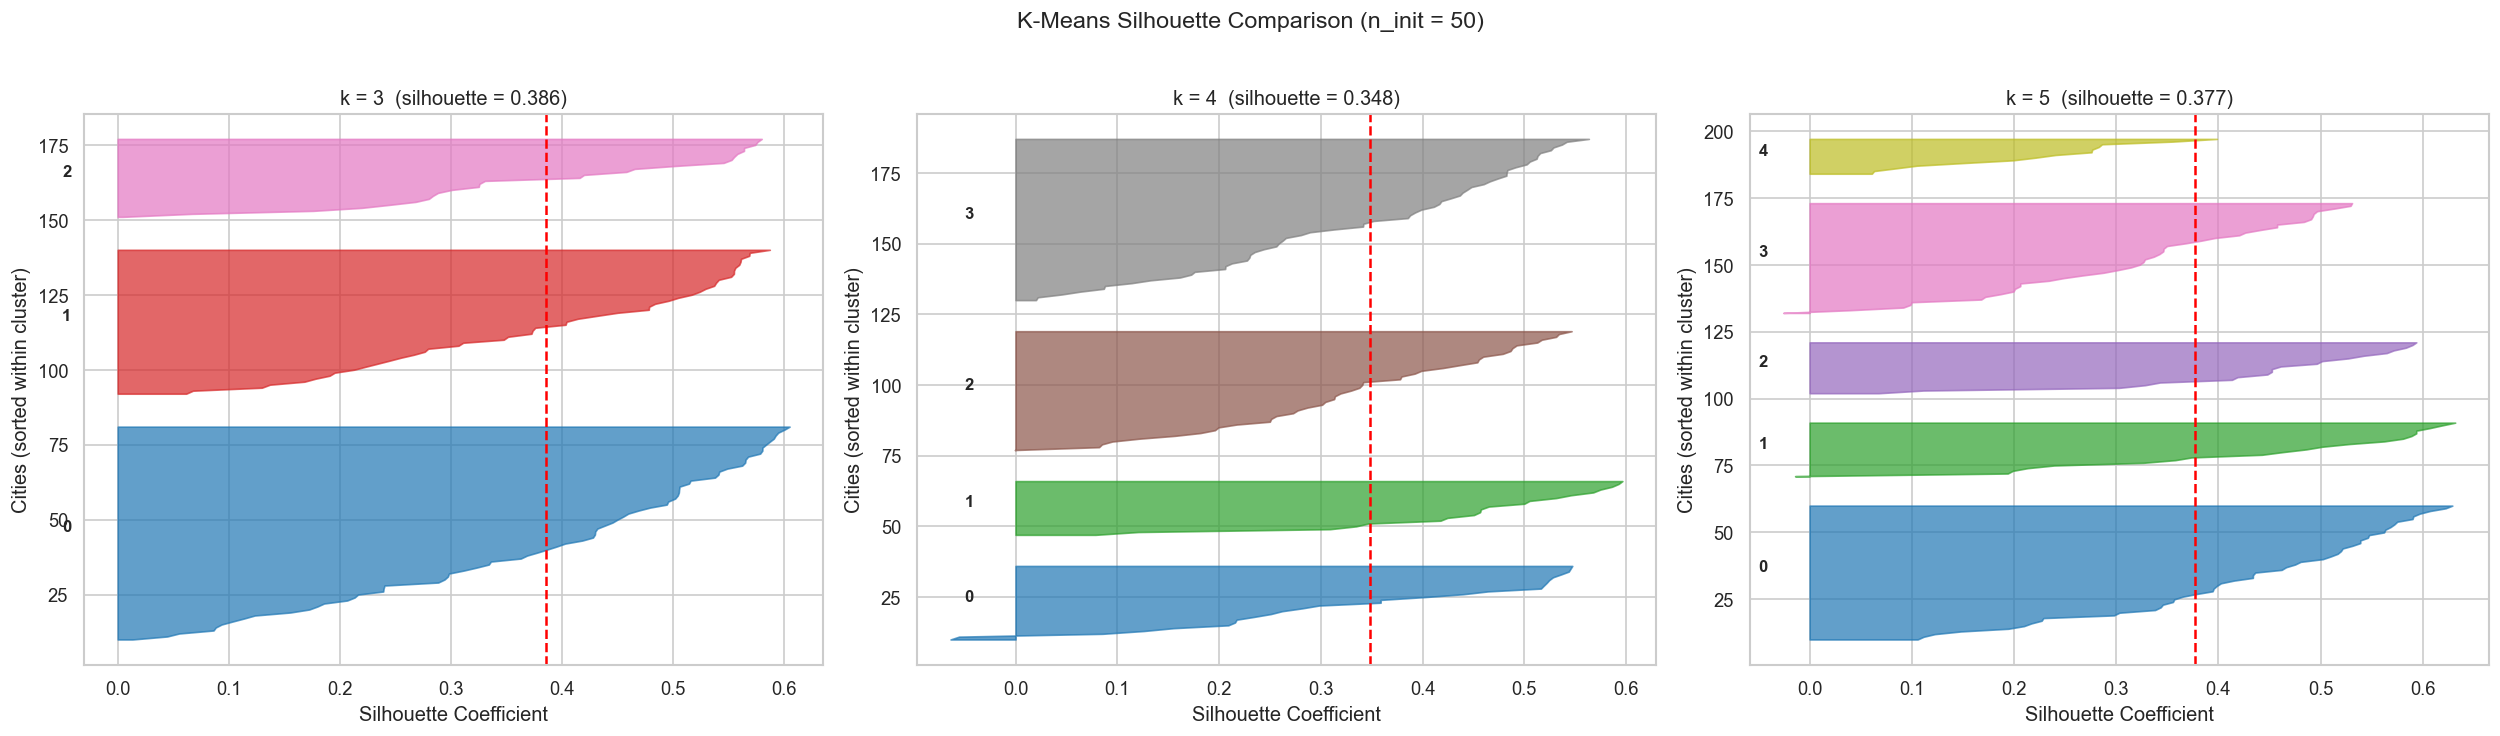

In [16]:
# Silhouette plots side-by-side for k = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, k in zip(axes, test_k_values):
    labs = kmeans_results[k]['labels']
    sil_vals = silhouette_samples(X, labs)
    avg_sil = kmeans_results[k]['silhouette']

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labs == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', ls='--', lw=1.5)
    ax.set_title(f'k = {k}  (silhouette = {avg_sil:.3f})', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cities (sorted within cluster)')

plt.suptitle('K-Means Silhouette Comparison (n_init = 50)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

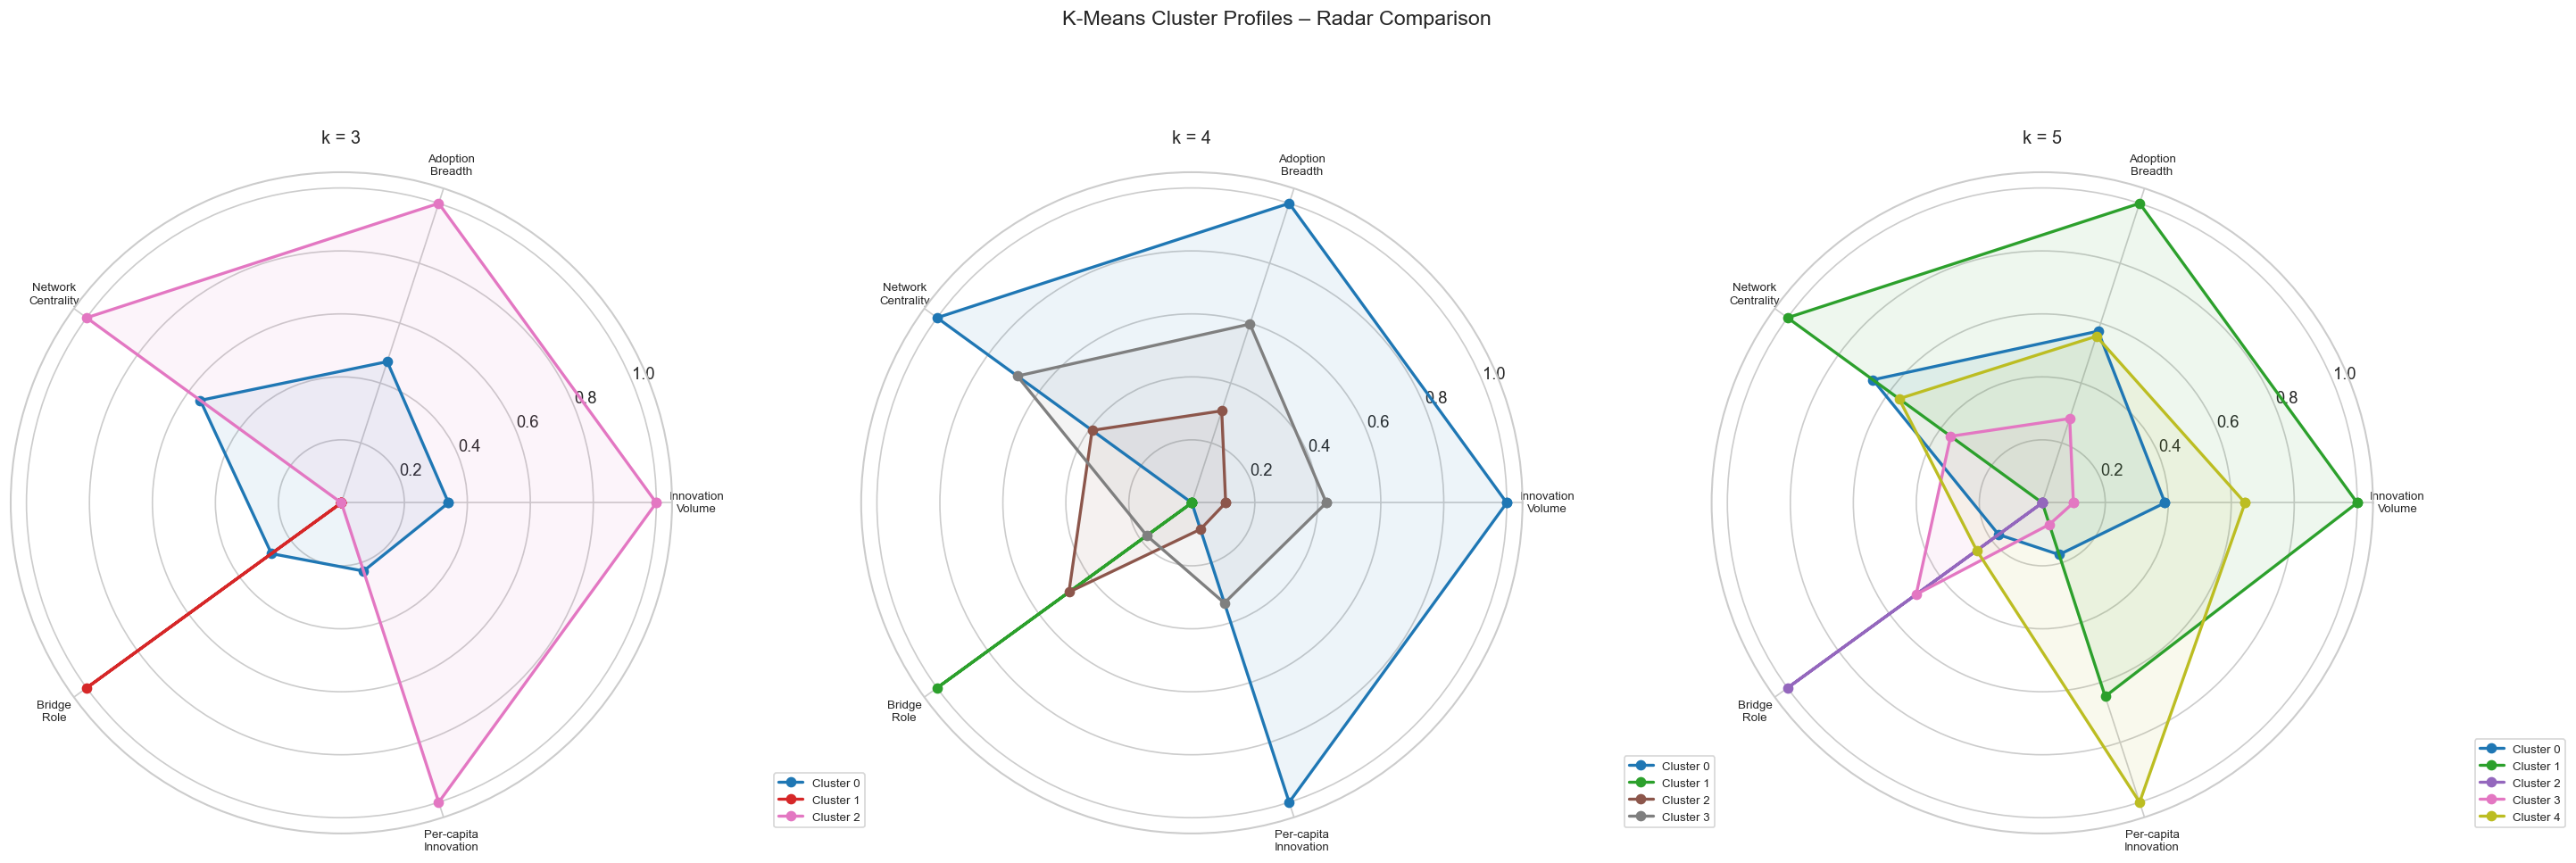

In [17]:
# Radar charts for k=3, 4, 5 side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw=dict(polar=True))

radar_cols = ['log_origination', 'log_adoption', 'log_degree',
              'log_betweenness', 'log_orig_rate']
radar_labels = ['Innovation\nVolume', 'Adoption\nBreadth', 'Network\nCentrality',
                'Bridge\nRole', 'Per-capita\nInnovation']
n_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

for ax, k in zip(axes, test_k_values):
    centroids_std = pd.DataFrame(
        kmeans_results[k]['model'].cluster_centers_, columns=cluster_features)
    centroids_norm = (centroids_std - centroids_std.min()) / (
        centroids_std.max() - centroids_std.min() + 1e-9)

    for cid in range(k):
        vals = centroids_norm.iloc[cid][radar_cols].tolist()
        vals += vals[:1]
        color = plt.cm.tab10(cid / k)
        ax.plot(angles, vals, 'o-', lw=2, label=f'Cluster {cid}', color=color)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_title(f'k = {k}', fontsize=12, pad=20)
    ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=8)

plt.suptitle('K-Means Cluster Profiles – Radar Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

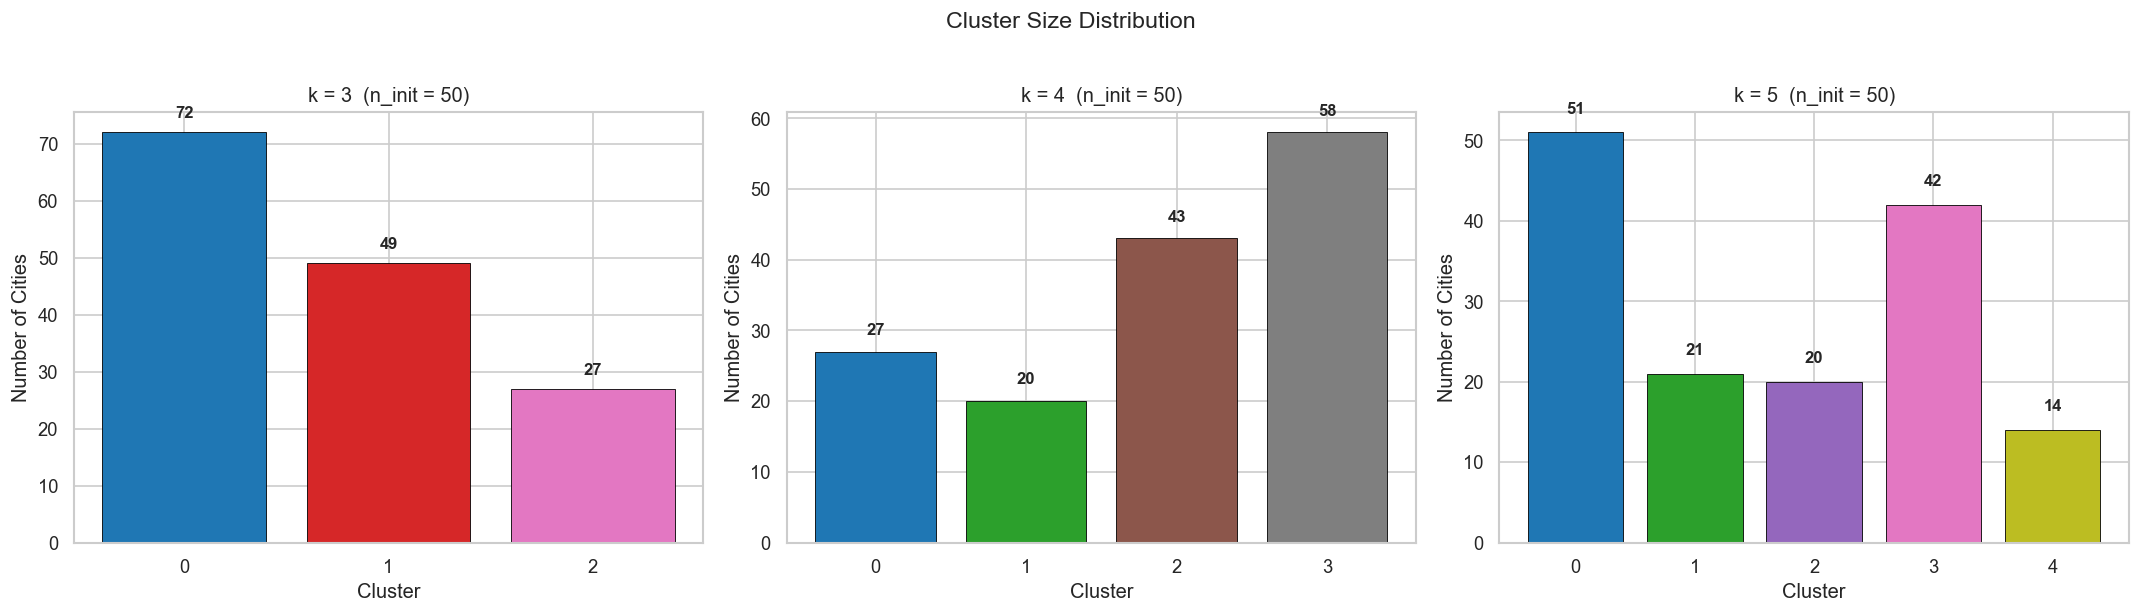

In [18]:
# Cluster size distribution for k = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, test_k_values):
    labs = kmeans_results[k]['labels']
    sizes = pd.Series(labs).value_counts().sort_index()
    colors = [plt.cm.tab10(i / k) for i in sizes.index]
    bars = ax.bar(sizes.index, sizes.values, color=colors, edgecolor='black', lw=0.5)
    for bar, val in zip(bars, sizes.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Cities')
    ax.set_title(f'k = {k}  (n_init = {N_INIT_HIGH})', fontsize=12)
    ax.set_xticks(range(k))

plt.suptitle('Cluster Size Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 9.7 – DBSCAN: Density-Based Clustering

DBSCAN does **not** require a pre-set number of clusters. It discovers arbitrarily shaped clusters
and labels low-density points as noise (−1). We tune `eps` using the **k-distance graph** method
and evaluate several `min_samples` values.

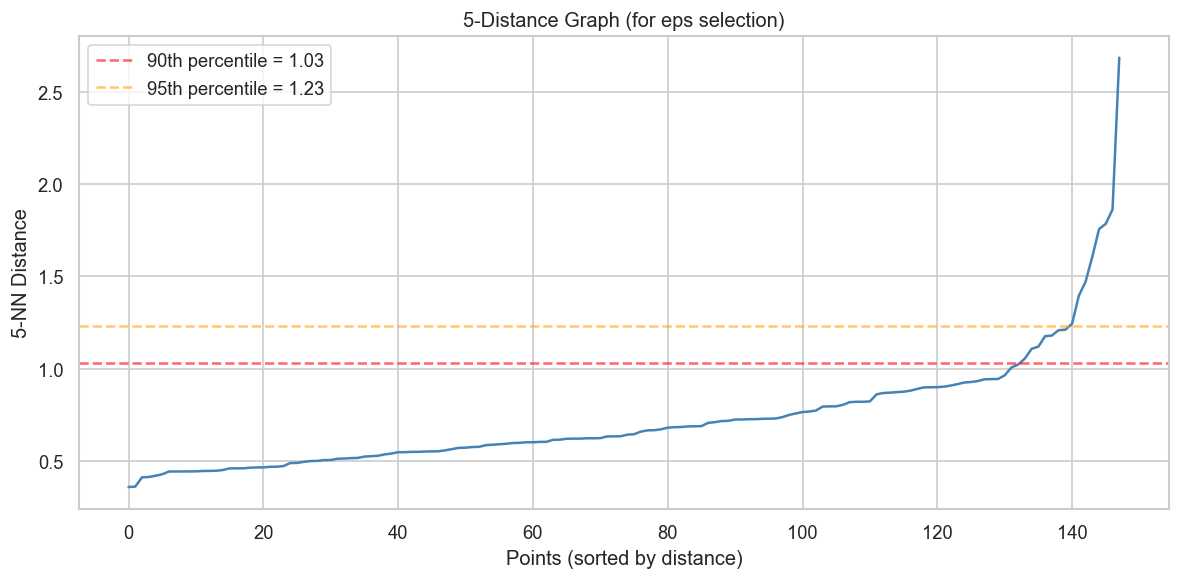

Distance percentiles:
  P50 = 0.639
  P75 = 0.833
  P85 = 0.928
  P90 = 1.033
  P95 = 1.233


In [19]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance graph to guide eps selection
k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_dist = np.sort(distances[:, k_nn - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, lw=1.5, color='steelblue')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title(f'{k_nn}-Distance Graph (for eps selection)')
ax.axhline(y=np.percentile(k_dist, 90), color='red', ls='--', alpha=0.6,
           label=f'90th percentile = {np.percentile(k_dist, 90):.2f}')
ax.axhline(y=np.percentile(k_dist, 95), color='orange', ls='--', alpha=0.6,
           label=f'95th percentile = {np.percentile(k_dist, 95):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Distance percentiles:')
for p in [50, 75, 85, 90, 95]:
    print(f'  P{p} = {np.percentile(k_dist, p):.3f}')

In [20]:
# Grid search over eps and min_samples
eps_candidates = np.arange(0.8, 2.6, 0.2).round(2)
min_samples_candidates = [3, 5, 7, 10]

dbscan_grid = []

for eps in eps_candidates:
    for ms in min_samples_candidates:
        db = DBSCAN(eps=eps, min_samples=ms)
        labs = db.fit_predict(X)
        n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise = (labs == -1).sum()
        noise_pct = n_noise / len(labs) * 100

        sil = silhouette_score(X, labs) if n_clusters >= 2 else np.nan

        dbscan_grid.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'noise_pct': noise_pct, 'silhouette': sil,
        })

dbscan_grid_df = pd.DataFrame(dbscan_grid)
print('DBSCAN Grid Search Results:')
display(dbscan_grid_df.dropna(subset=['silhouette'])
        .sort_values('silhouette', ascending=False)
        .head(15).round(4))

DBSCAN Grid Search Results:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
1,0.8,5,2,22,14.8649,0.2993
2,0.8,7,2,32,21.6216,0.2646
8,1.2,3,2,3,2.0270,0.2608
4,1.0,3,2,5,3.3784,0.2582
0,0.8,3,4,11,7.4324,0.1992


In [21]:
# Select best DBSCAN config (highest silhouette with ≥2 clusters and noise < 40%)
viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 40')

if len(viable) == 0:
    print('⚠️  No viable DBSCAN config found; relaxing noise threshold to 60%')
    viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 60')

best_db_row = viable.sort_values('silhouette', ascending=False).iloc[0]
BEST_EPS = best_db_row['eps']
BEST_MS  = int(best_db_row['min_samples'])

print(f'Best DBSCAN: eps={BEST_EPS}, min_samples={BEST_MS}')
print(f'  → {int(best_db_row["n_clusters"])} clusters, '
      f'{int(best_db_row["n_noise"])} noise points ({best_db_row["noise_pct"]:.1f}%), '
      f'silhouette={best_db_row["silhouette"]:.4f}')

db_best = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
db_labels = db_best.fit_predict(X)

df['dbscan_cluster'] = np.nan
df.loc[X_raw.index, 'dbscan_cluster'] = db_labels

print(f'\nCluster distribution:')
print(pd.Series(db_labels).value_counts().sort_index().to_string())

Best DBSCAN: eps=0.8, min_samples=5
  → 2 clusters, 22 noise points (14.9%), silhouette=0.2993

Cluster distribution:
-1     22
 0     16
 1    110


DBSCAN Cluster Profiles (mean values):


dbscan_cluster,-1,0,1
origination_count,128.82,297.75,8.25
adoption_count,400.09,1046.50,123.75
weighted_degree,2387.82,7344.19,1534.12
betweenness,0.01,0.00,0.01
origination_rate_pop,339.05,33.26,3.46
population_million,3.41,11.61,6.13
gdp_per_capita,54423.64,41325.94,39640.18
entity_count,207.59,835.50,90.98
n_cities,22.00,16.00,110.00


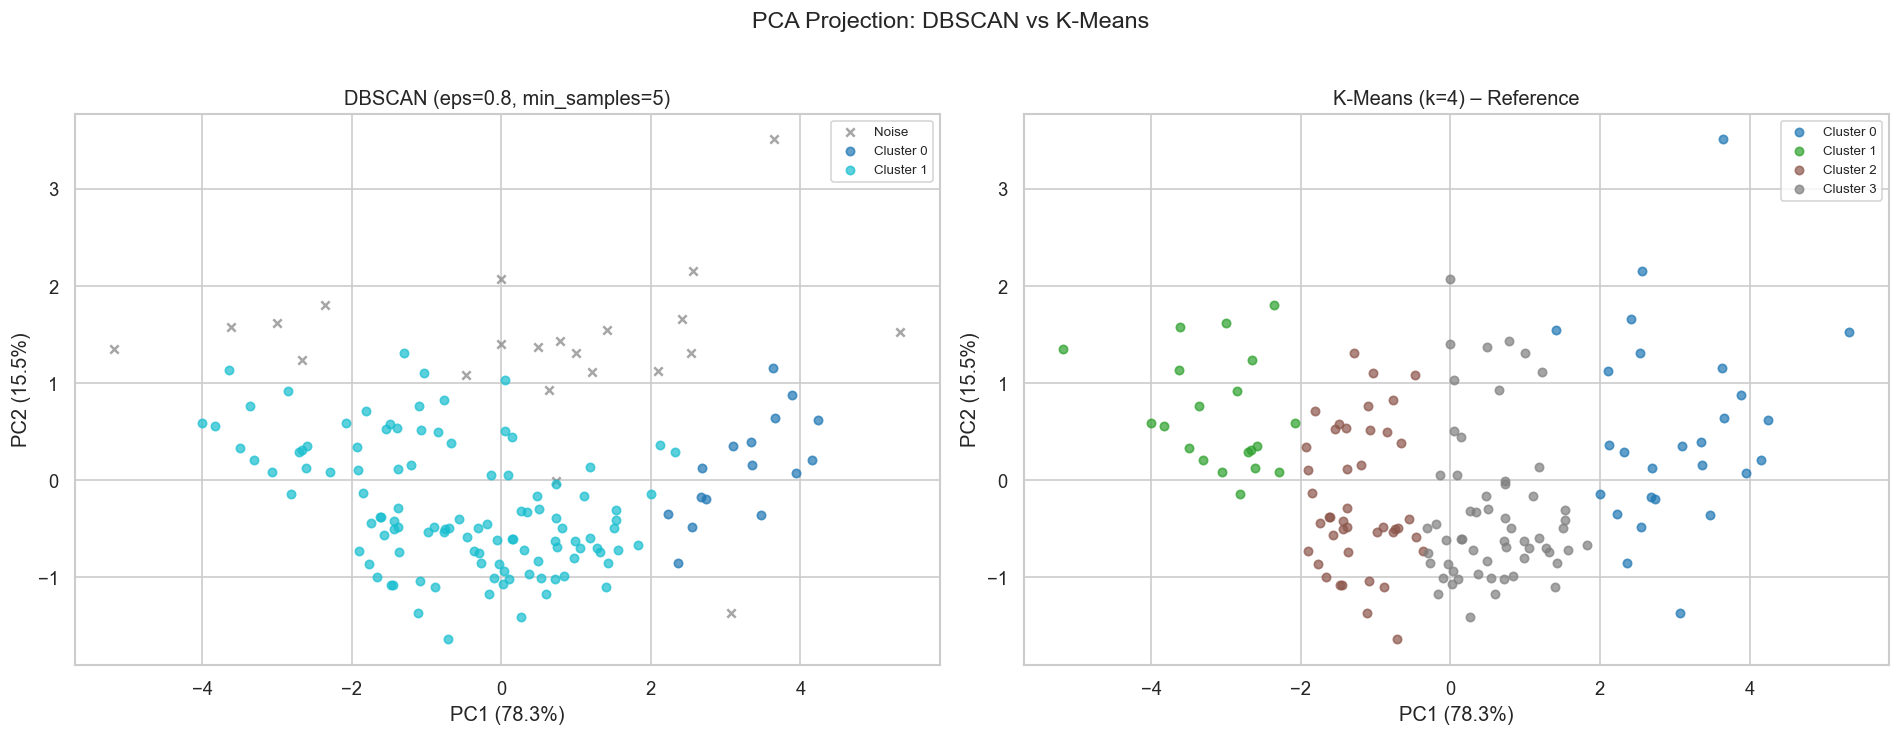

In [22]:
# DBSCAN cluster profiles
db_profile_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'population_million',
    'gdp_per_capita', 'entity_count',
]

db_df = df.dropna(subset=['dbscan_cluster']).copy()
db_df['dbscan_cluster'] = db_df['dbscan_cluster'].astype(int)

db_profiles = db_df.groupby('dbscan_cluster')[db_profile_cols].mean().round(2)
db_profiles['n_cities'] = db_df.groupby('dbscan_cluster').size()
print('DBSCAN Cluster Profiles (mean values):')
display(db_profiles.T)

# DBSCAN scatter (first two PCA components for vis)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
ax = axes[0]
unique_labels = sorted(set(db_labels))
for lab in unique_labels:
    mask = db_labels == lab
    color = 'grey' if lab == -1 else plt.cm.tab10(lab / max(unique_labels + [1]))
    label_str = 'Noise' if lab == -1 else f'Cluster {lab}'
    marker = 'x' if lab == -1 else 'o'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, marker=marker,
               s=25, alpha=0.7, label=label_str)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS})')
ax.legend(fontsize=8)

# K-Means k=4 for reference
ax = axes[1]
km4_labs = kmeans_results[4]['labels']
for cid in sorted(set(km4_labs)):
    mask = km4_labs == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=plt.cm.tab10(cid / 4),
               s=25, alpha=0.7, label=f'Cluster {cid}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means (k=4) – Reference')
ax.legend(fontsize=8)

plt.suptitle('PCA Projection: DBSCAN vs K-Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 9.8 – GMM: Gaussian Mixture Model (Soft Clustering)

GMM allows **soft (probabilistic) assignment** — each city gets a probability of belonging to each
cluster rather than a hard label. We use BIC/AIC to select the optimal number of components
and compare with K-Means results.

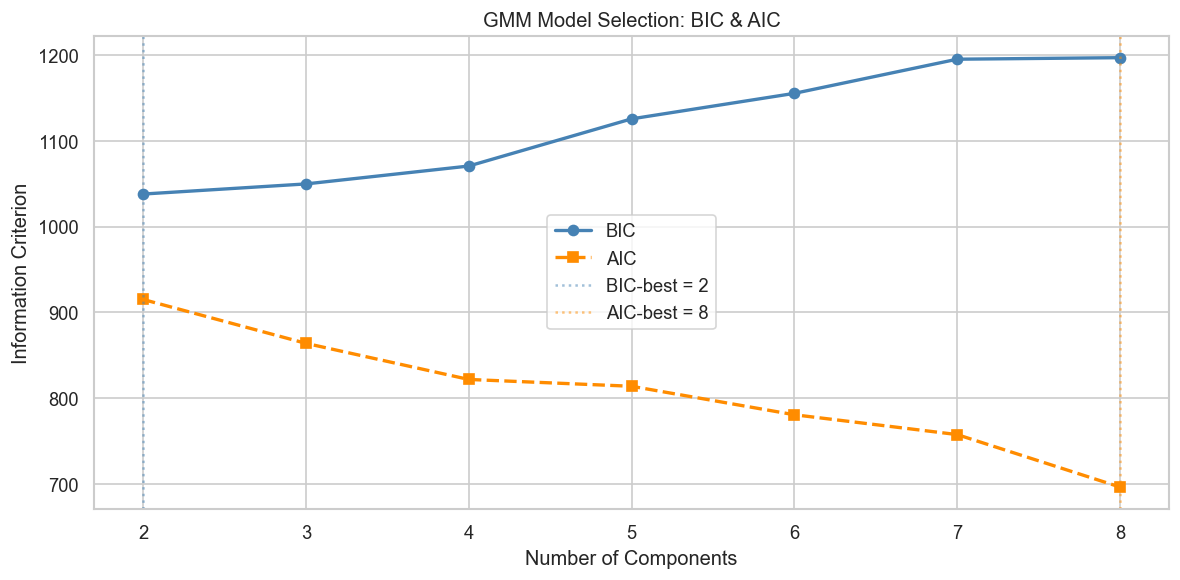

BIC-optimal: k = 2
AIC-optimal: k = 8


In [23]:
from sklearn.mixture import GaussianMixture

# BIC / AIC model selection
gmm_k_range = range(2, 9)
bics, aics = [], []

for k in gmm_k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42, max_iter=500)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(gmm_k_range), bics, 'o-', lw=2, color='steelblue', label='BIC')
ax.plot(list(gmm_k_range), aics, 's--', lw=2, color='darkorange', label='AIC')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection: BIC & AIC')
ax.set_xticks(list(gmm_k_range))
ax.legend()

best_gmm_k_bic = list(gmm_k_range)[np.argmin(bics)]
best_gmm_k_aic = list(gmm_k_range)[np.argmin(aics)]
ax.axvline(best_gmm_k_bic, color='steelblue', ls=':', alpha=0.5,
           label=f'BIC-best = {best_gmm_k_bic}')
ax.axvline(best_gmm_k_aic, color='darkorange', ls=':', alpha=0.5,
           label=f'AIC-best = {best_gmm_k_aic}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'BIC-optimal: k = {best_gmm_k_bic}')
print(f'AIC-optimal: k = {best_gmm_k_aic}')

In [24]:
# Fit GMM with k = 3, 4, 5 for comparison (aligned with K-Means tests)
gmm_results = {}

for k in test_k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42, max_iter=500)
    gmm.fit(X)
    labs = gmm.predict(X)
    probs = gmm.predict_proba(X)

    sil = silhouette_score(X, labs)
    ch  = calinski_harabasz_score(X, labs)
    db  = davies_bouldin_score(X, labs)

    gmm_results[k] = {
        'model': gmm,
        'labels': labs,
        'probs': probs,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    }

    print(f'GMM k={k}  |  Sil={sil:.4f}  |  CH={ch:.1f}  |  DB={db:.3f}  |  '
          f'BIC={gmm.bic(X):.1f}  |  AIC={gmm.aic(X):.1f}')

gmm_comp_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m not in ('model', 'labels', 'probs')}
    for k, vals in gmm_results.items()
}).T
gmm_comp_df.index.name = 'k'
print('\n── GMM Comparison Table ──')
display(gmm_comp_df.round(4))

GMM k=3  |  Sil=0.2835  |  CH=107.2  |  DB=1.084  |  BIC=1049.8  |  AIC=864.0
GMM k=4  |  Sil=0.2777  |  CH=75.5  |  DB=1.216  |  BIC=1070.6  |  AIC=821.9
GMM k=5  |  Sil=0.2344  |  CH=91.3  |  DB=1.146  |  BIC=1125.6  |  AIC=813.9

── GMM Comparison Table ──


,silhouette,calinski_harabasz,davies_bouldin,bic,aic
k,,,,,
3,0.2835,107.1513,1.0836,1049.7816,863.9544
4,0.2777,75.5220,1.2156,1070.6275,821.8588
5,0.2344,91.2831,1.1457,1125.6162,813.9061


GMM (k=4): 8 cities with max assignment probability < 0.7 (5.4%)

Most uncertain cities (lowest max probability):


,city,country,gmm_cluster,gmm_max_prob,origination_count,adoption_count,weighted_degree
107,Phoenix,United States,1,0.477,3.0,50,728
113,Brussels,Belgium,1,0.519,2.0,65,910
105,Nairobi,Kenya,1,0.585,2.0,42,584
104,Manchester,United Kingdom,1,0.600,1.0,57,956
114,Calgary,Canada,2,0.642,5.0,48,587
136,Johannesburg,South Africa,3,0.690,2.0,29,390
126,Rotterdam,Netherlands,3,0.696,2.0,28,435
90,Waterloo,Canada,2,0.700,8.0,79,1169


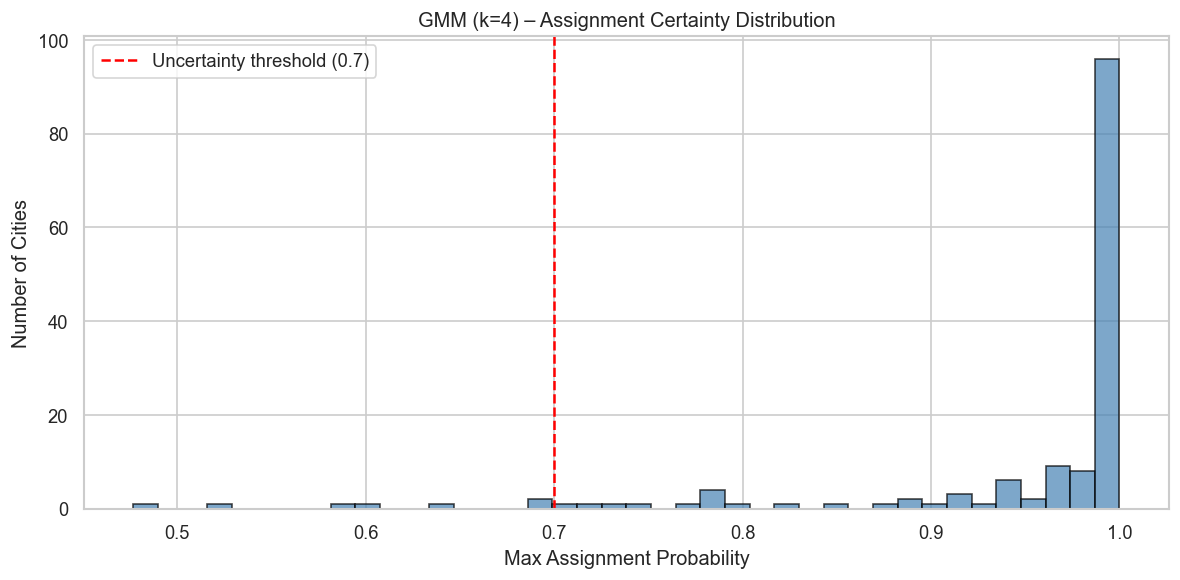

In [25]:
# GMM soft assignment: show cities with high uncertainty (max probability < 0.7)
GMM_K = 4
gmm4 = gmm_results[GMM_K]
probs4 = gmm4['probs']
labs4  = gmm4['labels']

max_prob = probs4.max(axis=1)
uncertain_mask = max_prob < 0.7
uncertain_idx = X_raw.index[uncertain_mask]

print(f'GMM (k={GMM_K}): {uncertain_mask.sum()} cities with max assignment probability < 0.7 '
      f'({uncertain_mask.sum()/len(max_prob)*100:.1f}%)\n')

df['gmm_cluster'] = np.nan
df.loc[X_raw.index, 'gmm_cluster'] = labs4
df['gmm_max_prob'] = np.nan
df.loc[X_raw.index, 'gmm_max_prob'] = max_prob

uncertain_cities = df.loc[uncertain_idx].sort_values('gmm_max_prob')[
    ['city', 'country', 'gmm_cluster', 'gmm_max_prob',
     'origination_count', 'adoption_count', 'weighted_degree']
].head(20)
uncertain_cities['gmm_cluster'] = uncertain_cities['gmm_cluster'].astype(int)
print('Most uncertain cities (lowest max probability):')
display(uncertain_cities.round(3))

# Distribution of max assignment probability
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_prob, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0.7, color='red', ls='--', lw=1.5, label='Uncertainty threshold (0.7)')
ax.set_xlabel('Max Assignment Probability')
ax.set_ylabel('Number of Cities')
ax.set_title(f'GMM (k={GMM_K}) – Assignment Certainty Distribution')
ax.legend()
plt.tight_layout()
plt.show()

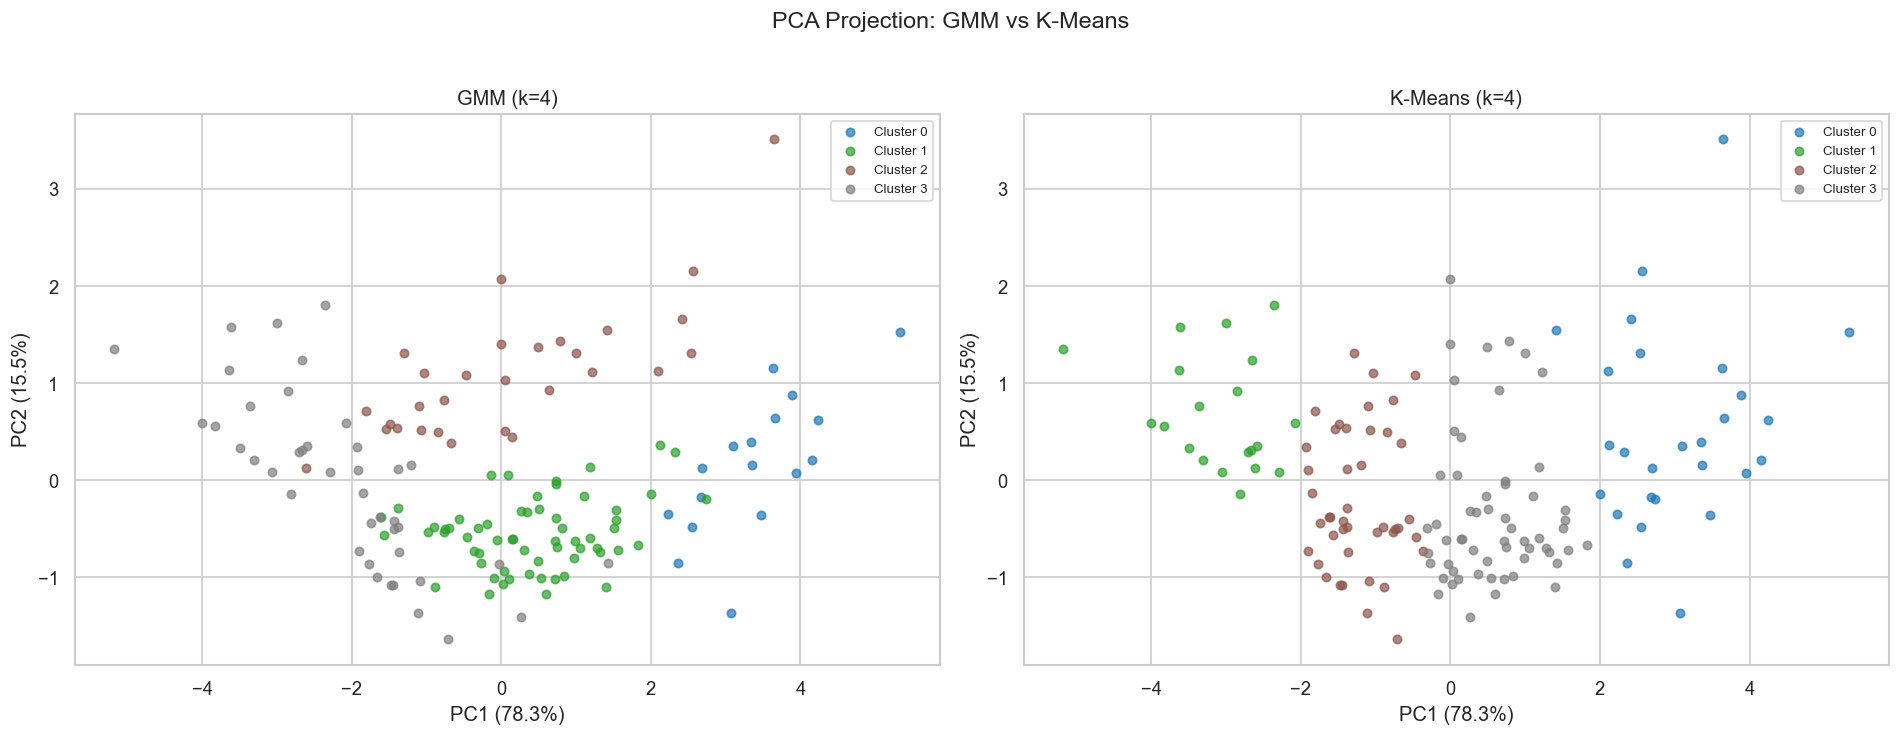


Agreement (K-Means vs GMM, k=4):
  Adjusted Rand Index (ARI) = 0.3400
  Normalised Mutual Info    = 0.4072


In [26]:
# GMM vs K-Means PCA scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, labs) in zip(axes, [
    (f'GMM (k={GMM_K})', labs4),
    (f'K-Means (k={GMM_K})', kmeans_results[GMM_K]['labels']),
]):
    for cid in sorted(set(labs)):
        mask = labs == cid
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=plt.cm.tab10(cid / GMM_K),
                   s=25, alpha=0.7, label=f'Cluster {cid}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('PCA Projection: GMM vs K-Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Agreement between GMM and K-Means (Adjusted Rand Index)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_results[GMM_K]['labels'], labs4)
nmi = normalized_mutual_info_score(kmeans_results[GMM_K]['labels'], labs4)
print(f'\nAgreement (K-Means vs GMM, k={GMM_K}):')
print(f'  Adjusted Rand Index (ARI) = {ari:.4f}')
print(f'  Normalised Mutual Info    = {nmi:.4f}')

---

## 9.9 – Comprehensive Comparison & Summary

We now compare all clustering approaches across multiple evaluation metrics
and summarise findings to justify the final model choice.

In [27]:
# Master comparison table
rows = []

for k in test_k_values:
    rows.append({
        'Method': f'K-Means (k={k})',
        'n_clusters': k,
        'Silhouette': kmeans_results[k]['silhouette'],
        'Calinski-Harabasz': kmeans_results[k]['calinski_harabasz'],
        'Davies-Bouldin': kmeans_results[k]['davies_bouldin'],
        'Noise %': 0.0,
        'Note': '',
    })

for k in test_k_values:
    rows.append({
        'Method': f'GMM (k={k})',
        'n_clusters': k,
        'Silhouette': gmm_results[k]['silhouette'],
        'Calinski-Harabasz': gmm_results[k]['calinski_harabasz'],
        'Davies-Bouldin': gmm_results[k]['davies_bouldin'],
        'Noise %': 0.0,
        'Note': f'BIC={gmm_results[k]["bic"]:.0f}',
    })

if len(viable) > 0:
    db_sil = best_db_row['silhouette']
    db_n = int(best_db_row['n_clusters'])
    db_ch = calinski_harabasz_score(X, db_labels) if db_n >= 2 else np.nan
    db_db = davies_bouldin_score(X, db_labels) if db_n >= 2 else np.nan
    rows.append({
        'Method': f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS})',
        'n_clusters': db_n,
        'Silhouette': db_sil,
        'Calinski-Harabasz': db_ch,
        'Davies-Bouldin': db_db,
        'Noise %': best_db_row['noise_pct'],
        'Note': f'{int(best_db_row["n_noise"])} noise points',
    })

master = pd.DataFrame(rows)
master = master.sort_values('Silhouette', ascending=False).reset_index(drop=True)
print('═' * 90)
print('MASTER COMPARISON TABLE – ALL CLUSTERING APPROACHES')
print('═' * 90)
display(master.round(4))

══════════════════════════════════════════════════════════════════════════════════════════
MASTER COMPARISON TABLE – ALL CLUSTERING APPROACHES
══════════════════════════════════════════════════════════════════════════════════════════


,Method,n_clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin,Noise %,Note
0,K-Means (k=3),3,0.3858,151.7979,0.8694,0.0000,
1,K-Means (k=5),5,0.3772,140.2086,0.9066,0.0000,
2,K-Means (k=4),4,0.3479,142.9872,0.9589,0.0000,
3,"DBSCAN (eps=0.8, ms=5)",2,0.2993,40.4459,1.6342,14.8649,22 noise points
4,GMM (k=3),3,0.2835,107.1513,1.0836,0.0000,BIC=1050
5,GMM (k=4),4,0.2777,75.5220,1.2156,0.0000,BIC=1071
6,GMM (k=5),5,0.2344,91.2831,1.1457,0.0000,BIC=1126


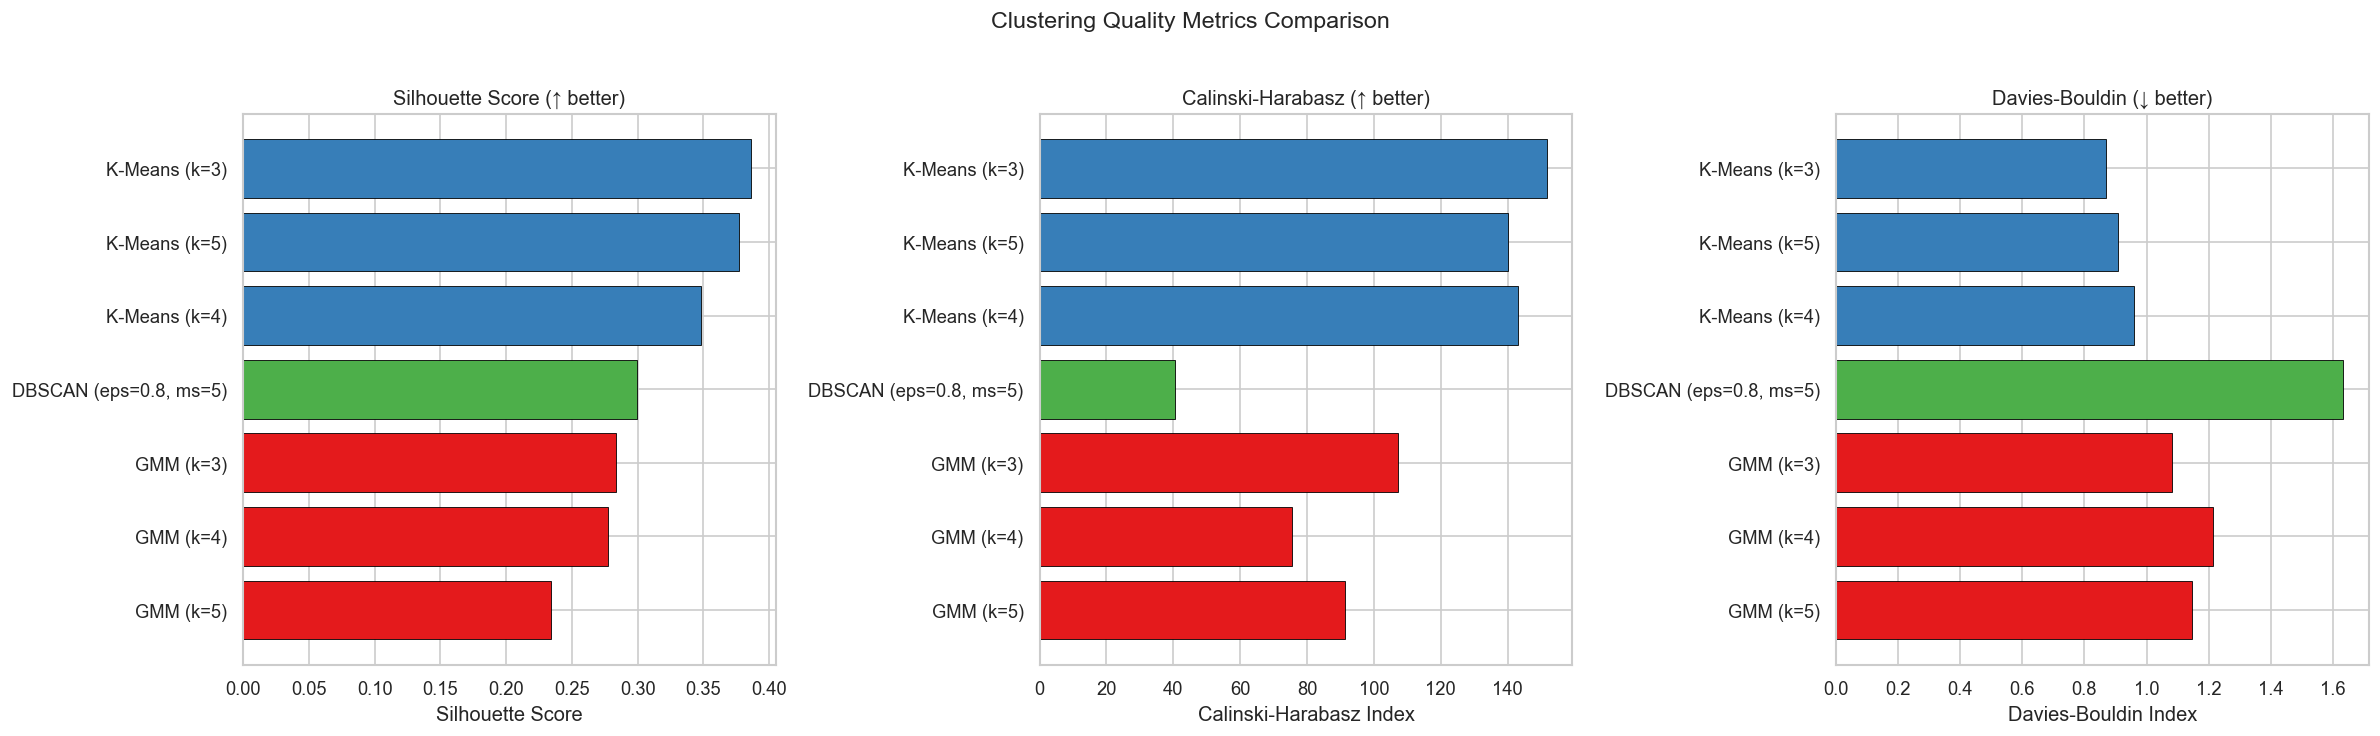

In [28]:
# Visual comparison: bar chart of Silhouette scores
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = master['Method'].tolist()
colors = ['#377eb8' if 'K-Means' in m else '#e41a1c' if 'GMM' in m else '#4daf4a'
          for m in methods]

# Silhouette (higher is better)
ax = axes[0]
bars = ax.barh(methods, master['Silhouette'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Silhouette Score')
ax.set_title('Silhouette Score (↑ better)')
ax.invert_yaxis()

# Calinski-Harabasz (higher is better)
ax = axes[1]
ax.barh(methods, master['Calinski-Harabasz'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Calinski-Harabasz Index')
ax.set_title('Calinski-Harabasz (↑ better)')
ax.invert_yaxis()

# Davies-Bouldin (lower is better)
ax = axes[2]
ax.barh(methods, master['Davies-Bouldin'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin (↓ better)')
ax.invert_yaxis()

plt.suptitle('Clustering Quality Metrics Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

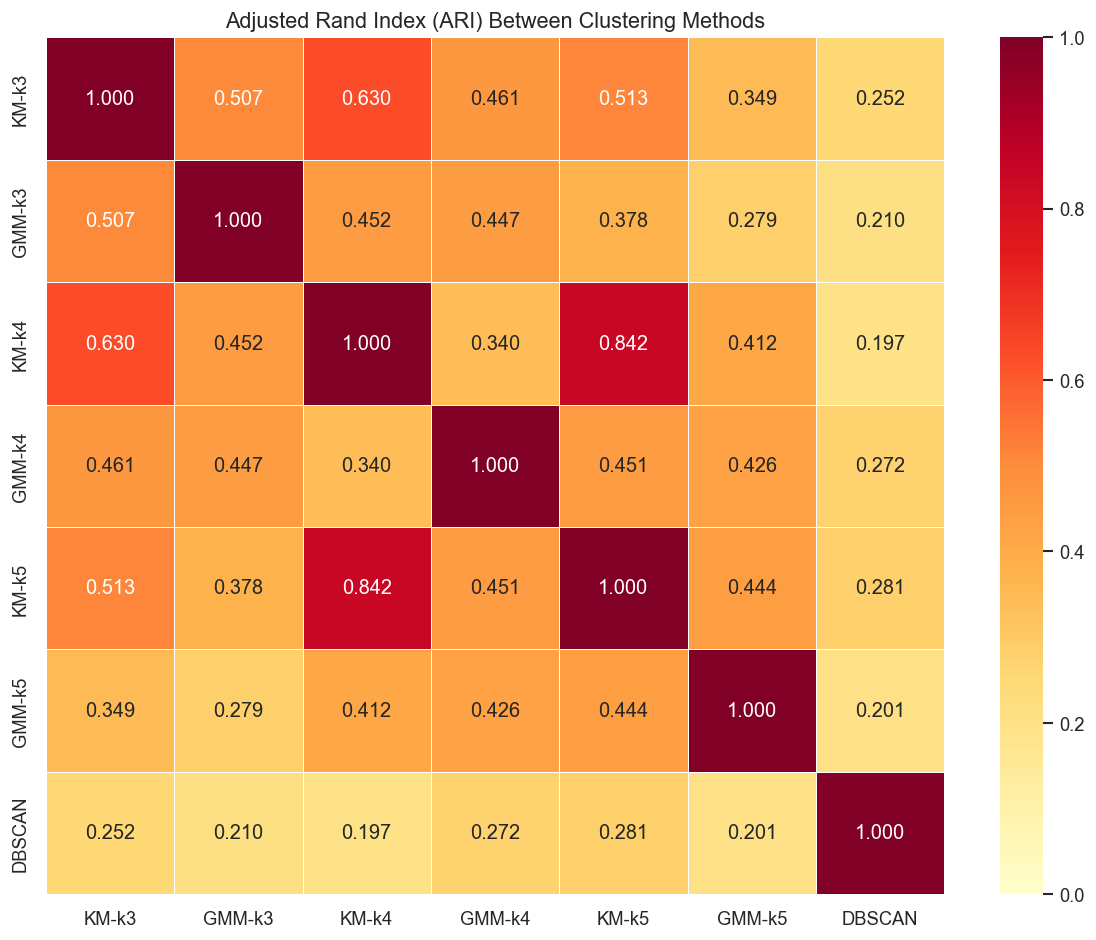

In [29]:
# Cross-method agreement matrix (ARI between all pairs)
all_label_sets = {}
for k in test_k_values:
    all_label_sets[f'KM-k{k}'] = kmeans_results[k]['labels']
    all_label_sets[f'GMM-k{k}'] = gmm_results[k]['labels']
all_label_sets['DBSCAN'] = db_labels

method_names = list(all_label_sets.keys())
n_methods = len(method_names)
ari_matrix = np.zeros((n_methods, n_methods))

for i in range(n_methods):
    for j in range(n_methods):
        ari_matrix[i, j] = adjusted_rand_score(
            all_label_sets[method_names[i]],
            all_label_sets[method_names[j]])

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names).round(3)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ari_df, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            fmt='.3f', linewidths=0.5, ax=ax)
ax.set_title('Adjusted Rand Index (ARI) Between Clustering Methods', fontsize=13)
plt.tight_layout()
plt.show()

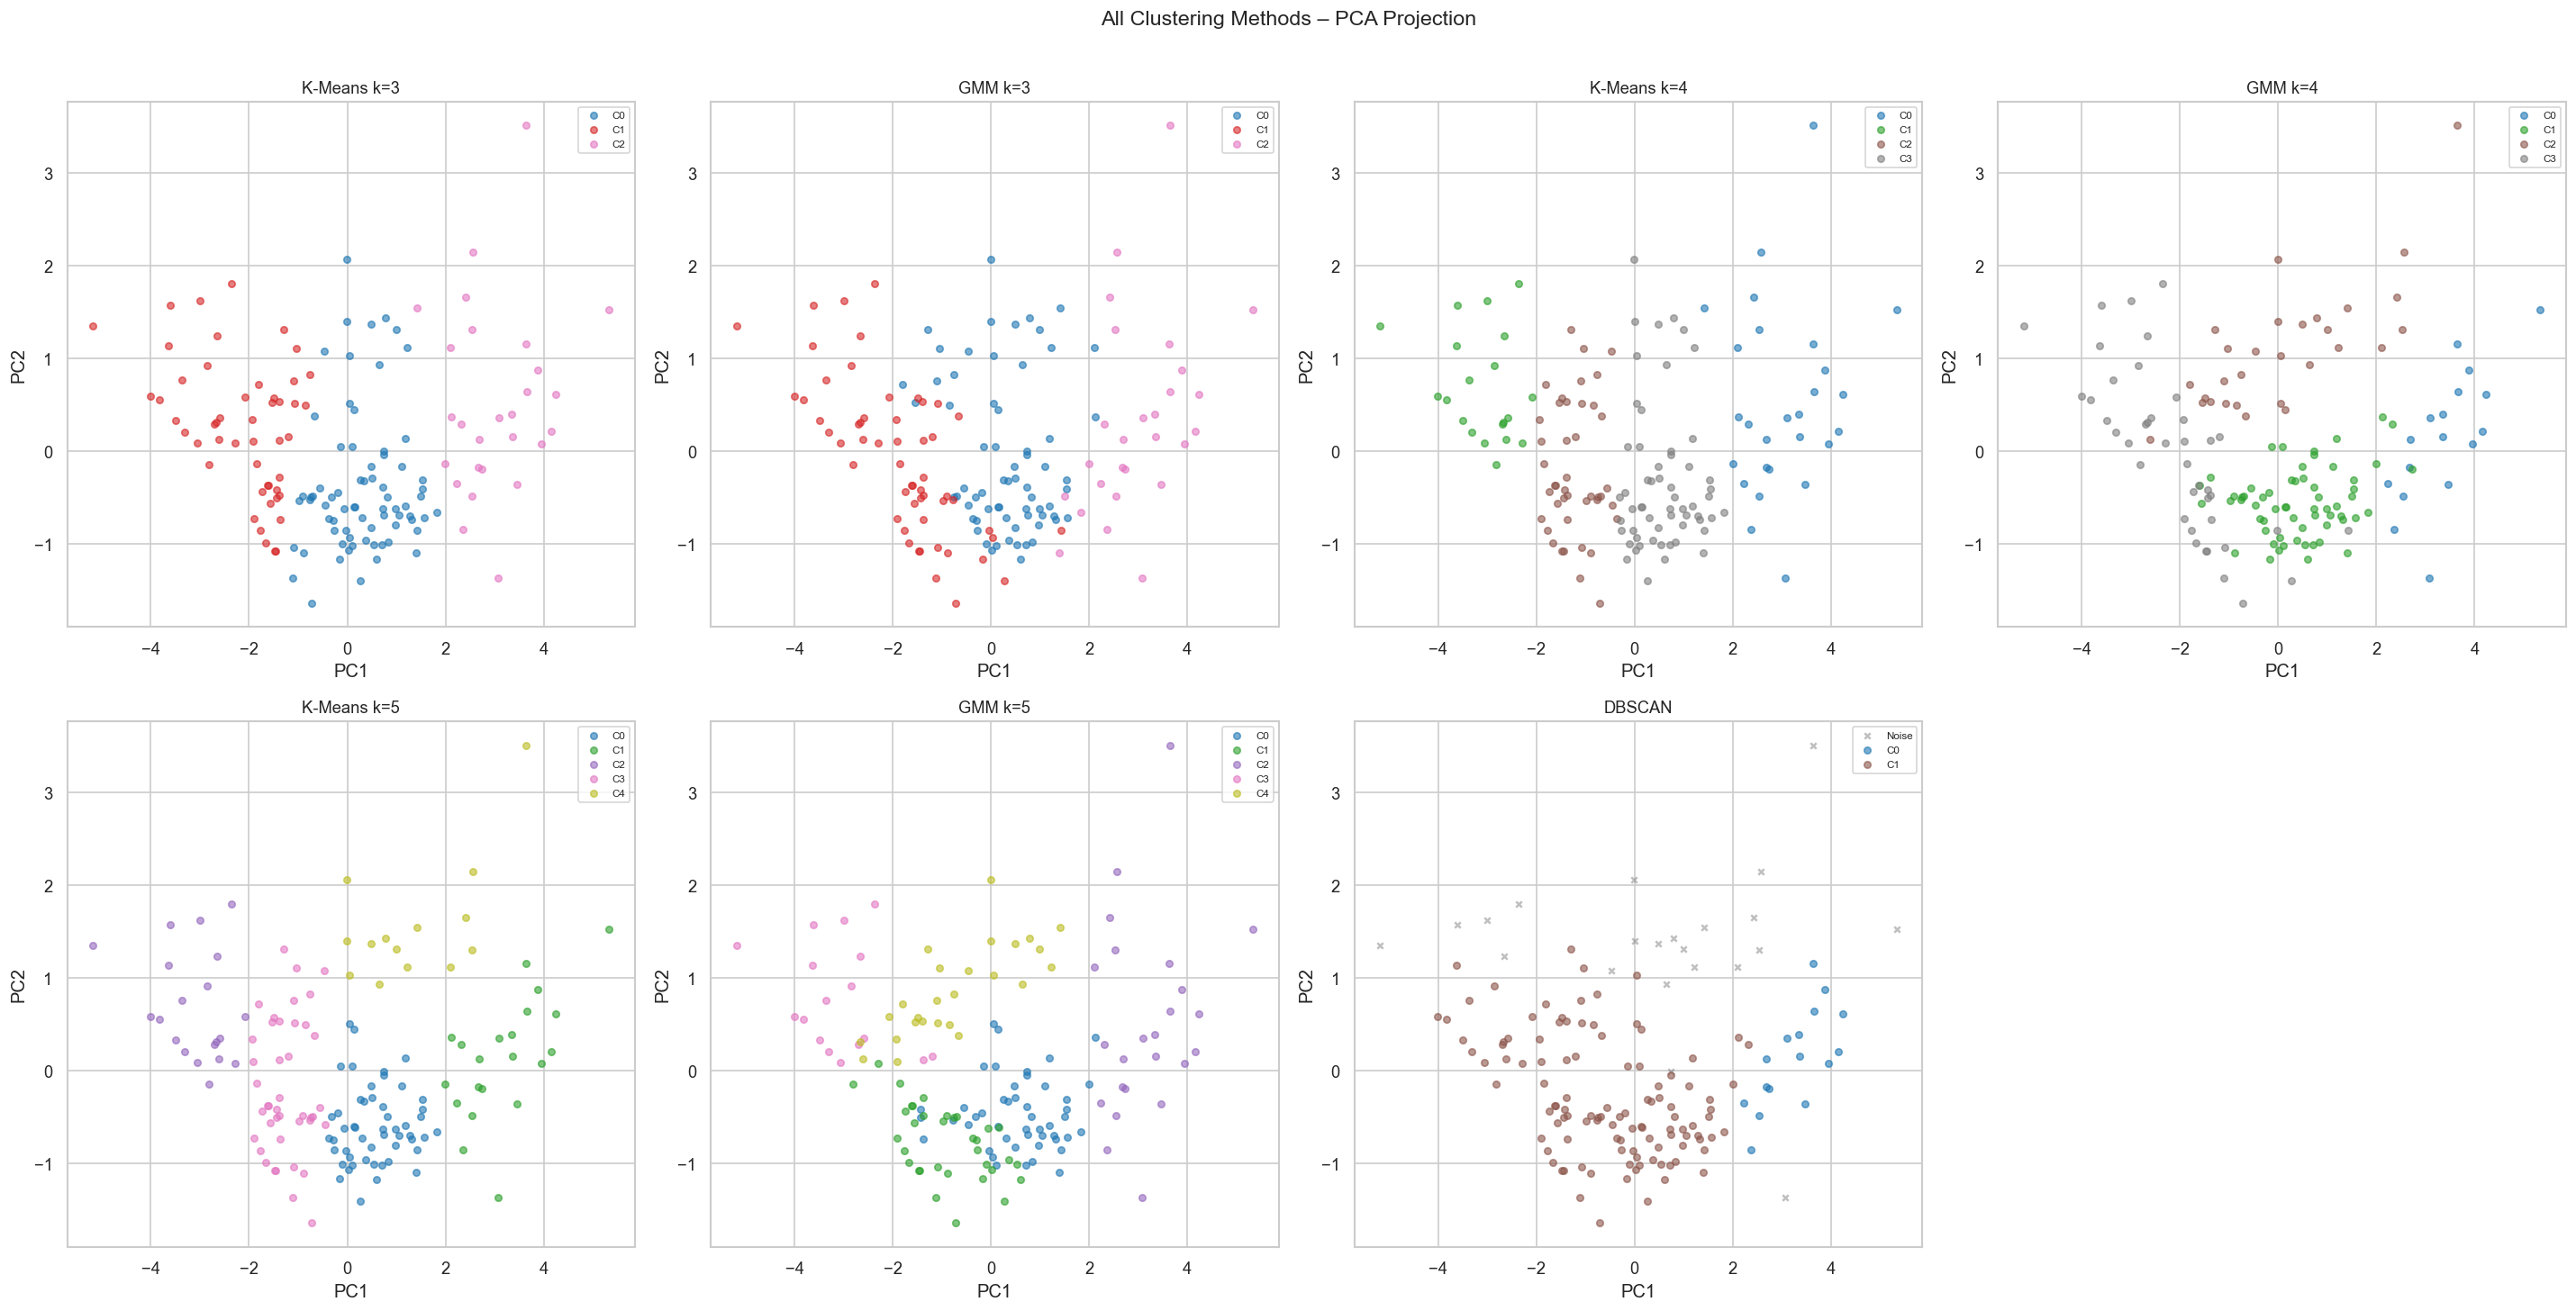

In [30]:
# PCA scatter: all methods side by side
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

plot_configs = []
for k in test_k_values:
    plot_configs.append((f'K-Means k={k}', kmeans_results[k]['labels'], k))
    plot_configs.append((f'GMM k={k}', gmm_results[k]['labels'], k))
plot_configs.append((f'DBSCAN', db_labels, max(db_labels) + 1 if max(db_labels) > 0 else 2))

for idx, (title, labs, max_k) in enumerate(plot_configs):
    if idx >= len(axes):
        break
    ax = axes[idx]
    unique = sorted(set(labs))
    for cid in unique:
        mask = labs == cid
        if cid == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='grey', marker='x',
                       s=15, alpha=0.5, label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=plt.cm.tab10(cid / max(max_k, 1)),
                       s=20, alpha=0.6, label=f'C{cid}')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Hide unused subplot
for idx in range(len(plot_configs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('All Clustering Methods – PCA Projection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.9.1 – Analysis Summary

**K-Means Parameter Sensitivity (k = 3, 4, 5, n_init = 50)**

| k | Silhouette | CH Index | DB Index | Interpretation |
|---|---|---|---|---|
| **k=3** | **0.386** (best) | 151.8 | **0.869** (best) | Merges Collaborators with hubs or emerging cities; loses a theoretically meaningful tier. Highest internal-metric scores, but too coarse for the four-role framework. |
| **k=4** | 0.348 | 143.0 | 0.959 | Matches the four-role theoretical framework (Hubs, Collaborators, Emerging, Peripheral). Balanced trade-off between parsimony and expressiveness. |
| **k=5** | 0.377 | 140.2 | 0.907 | Splits the large Peripheral cluster into two less interpretable sub-groups. Marginal metric improvement over k=4 at the cost of clarity. |

> Increasing `n_init` from 20 to 50 did not change the cluster assignments for any k, confirming that the original results were already stable.

**DBSCAN (best: eps=0.8, min_samples=5)**
- Discovered only **2 clusters** + 22 noise points (14.9%), silhouette = 0.299.
- The density-based approach does not suit this dataset well: city features form roughly convex, overlapping distributions without sharp density gaps.
- However, the 22 noise points (outlier cities) provide a useful **robustness check** — they represent atypical cities that do not fit neatly into any cluster.

**GMM (Gaussian Mixture Model)**
- BIC-optimal k = 2; AIC-optimal k = 8 — the two criteria diverge, suggesting the true structure is somewhere in between.
- At k=4, GMM yields silhouette = 0.278 (lower than K-Means 0.348), with only 8 cities (5.4%) showing assignment uncertainty (max prob < 0.7).
- ARI between GMM(k=4) and K-Means(k=4) = **0.340**, NMI = 0.407 — moderate agreement, indicating GMM captures a somewhat different but overlapping structure due to its ellipsoidal covariance modelling.
- Soft probabilities add nuance: boundary cities can be quantified by how split their memberships are, useful for identifying "bridge cities".

**Recommendation**: Retain **K-Means k=4** as the primary model for downstream analysis because:
1. **Theoretically motivated**: directly maps to the four-role typology (Hubs, Collaborators, Emerging, Peripheral).
2. **Metrically solid**: k=4 is close to k=3 in silhouette (0.348 vs 0.386) and outperforms GMM and DBSCAN.
3. **Stable**: increasing n_init from 20→50 produced identical assignments.
4. **Complementary insights**: GMM soft probabilities serve as a supplementary uncertainty measure; DBSCAN noise labels flag outlier cities for robustness checks.